In [ ]:
# 2200 lines code, 19 solved cases, case 338 is better suited for objective
# cas 338 is a basic in using objective
# cages is depreciated, now, it is time to fix the dimension module
# and hyberdize it with objects related work

In [ ]:
# alright, system is more like of a kluge, 20 tasks caught, hybrid between old and new
# system.
# current goals:
# 1) set_obj_on_train on tasks with no similar dim, mostly undeduced: find how can you
# use core_knowledge on the input to derive output with no similar dim to input
# This is a critical layer of abstraction and must be accomplished
# start with 345, 48, 66, 105, 129, 151, 217, 290

# 2) hook up the edge and the neighbour cases by 
#   1) chekcpoint of whether to go with whatever we have in the objectives
#   or to only apply completed objectives
#   2) massaging the test_objective using the running_objective
#   3) apply test objective using core knowledge on the test inputs to spit test output

# 3) dimension_cognification to use objects, some simple cases were identified
#    here we find the solution and the dimensions instantanously
# 4) add more information from neihgbors.
# 5) 

In [ ]:
# After global objectification and test_expectation, we are confounded and intimidated by how each
# prior-knowledge requires different logic in terms of evaluation, testing, building an output.
# For ex: we need to screen flips, screen dimensions, screen cages: how can these be integrated
# or expressed within the objective system.
# With the objective_oriented approach: we need to massage test_expectations and allow it to work with
# cases in which not is_similar_dim and systems with no global_bg

# Artificial cognition is spider like, prior knowledge can't be looked at similarly, eventhough we did everything
# to decipher some aspects of prior knowledge, but the task in general can abstractedly classified as follows:
# 1) Output = global operation on the entire array ex: flips, dimension contraction, expansion
# 2) Output = leverage of certain attributes of the input array: objectives such as removing noise, edges, nb, dt, object output, etc.
#    output = completed the missing part of input (must conclude of the non-missing part): reflection, etc
# 3) Output = Operation on a certain attribute of the input array: get an object and rotate it 90 degrees

# Probably one way to tackle the above problem is to assume is_similar_dim on all objectives and have an extra
# layer of intelligence to factor in any cognified dimension in a consecutive manner
# As an example: case 345 is based on outputting a single value with edges == 0 (captured), the presence of nil
# in an objective can signal dimesnion work but we need to organize the way the machine thinks

# The goal is build a system that allows the incorporation of prior knowledge without having to modify
# or add anything to the book-keeping logic, this layer of abstraction seems to be what we are hitting at this 
# point. 

# parallel and integrated intelligent circuits
# induction tries to solve the output/dimension simultaneously
# the separation between induction and dimesnionWorks need to be re-evaluated

# We need to include dimension in the objective function not only because
# the system is expected to predict dimensions of the output but also becausue
# dimensions of objects can determine the outputs

# a system that tests flips on the whole array must be capable of exercising the same type
# of tests on objects of the array

# the objective must include dimesnion
# We need more abstraction so as to be able to automate general intelligence
# After satisfying the objective, the hassle of building an output must be crushed:
# this must be one system of creating outputs and must be flexible enough to accomodate
# new unseen cases

# 1) apply globally on the entire input (case 1 above): just transformation, no starting array
# 2) apply locally on input (case 2 above): detect and modify
# fill the missing part of an input (case 4 above): solve and modify
# 3) apply on an all zero input: detect and add to zero
#  extract from input (case 3 above): extract, apply transformation (flip for ex) no starting array

In [ ]:
# we have to instill the global inductive logic using the cases we know we can solve

In [1]:
from inductive_core_knowledge import * 

In [2]:
def print_arrays(case_num):
    this_task = TaskManager(tt[case_num])
    this_task.brief_task()
    return this_task

In [3]:
from pathlib import Path
data_path = Path("/home/hshallal/Desktop/ARCsolver/data/")
training_path = data_path / 'training'
tt = load_set(training_path)

In [4]:
from timeit import default_timer as timer
start = timer()
today_analysis = []
for n in range(len(tt)):
    print(n)
    this_task = Inductive(tt[n])
#     print(this_task.solved)
#     print(this_task.mechanisms)
#     print('running_objective: ', this_task.running_objective)
#     print('is_complete_objective: ', this_task.is_complete_objective)
#     print('test_objective: ', this_task.test_objective)
#     print('test_running_objective: ', this_task.test_running_objective)
    today_analysis.append(this_task)
    

serialize(today_analysis, 'assets/today_analysis')
end = timer()
print("It took this number of seconds: ", end - start)
print(len(today_analysis))
# It took this number of seconds: 1015




0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


/home/hshallal/Desktop/ARCsolver/utils.py:493: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  target_indices = (np.argwhere(in_ == x[0]), np.argwhere(out_ == x[1]))


20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289


In [5]:
knowns = load_serialized('assets/solved_indices_for_the_day.pkl')

In [6]:
previous_analysis = load_serialized('assets/today_analysis')

In [7]:
to_hook_up = [1, 345, 119, 186, 250, 293, 337]
to_figure_out = [345, 48, 66, 105, 129, 151, 217, 290]

In [8]:
# # check 12
to_compare = []
for n in range(400):
    this_task = previous_analysis[n]
    if this_task.is_complete_objective:
        to_compare.append(n)
        


In [9]:
to_compare_earlier = load_serialized('assets/to_compare')

In [10]:
len(to_compare_earlier), len(to_compare)

(175, 171)

In [11]:
diff = [x for x in to_compare_earlier if x not in to_compare]

In [12]:
serialize(to_compare, 'assets/to_compare')

In [13]:
# 23 has prior knoweldge which intersect and offers no value
# we need to make sure that when we set an objective on prior knowledge, we check the 
# internal validity of the prior knowledge to differentiate between the two arms or we don't have anything to work
# with

In [35]:
def enforce_global_objective(test_objective, global_objective):
    for n in range(len(test_objective)):
        this_test_objective = test_objective[n]
        included_in_test = []
        for x in range(len(this_test_objective)):
            for y in range(len(global_objective)):
                print('this_test_objective[x]: ', this_test_objective[x])
                print('global_objective[y]: ', global_objective[y])
                test_len = len(this_test_objective[x])
                print(len(global_objective[y]) >= test_len)
                print(global_objective[y][0:test_len] == this_test_objective[x])
                
                if len(global_objective[y]) >= test_len and global_objective[y][0:test_len] == this_test_objective[x]:
                    included_in_test.append(x)  
        print(included_in_test)        
        not_included = [l for l in range(len(this_test_objective)) if l not in included_in_test]
        print(not_included)
        if len(not_included) == 0:
            return global_objective
        else:
            for to_massage in not_included:
                this_extra = this_test_objective[to_massage] # [('nonbg4', 'nonbg4'), ('nonbg4', 'bg')]
                if len(this_extra) == 2:
                    first, second = this_extra[0], this_extra[1]
                    first_same, second_same = this_extra[0][0] == this_extra[0][1], this_extra[1][0] == this_extra[1][1]
                    
                    
                    
                    
                

In [62]:
def is_all_nonbg_ass_leads(this_obj):
    for x in this_obj:
        if type(x) == tuple and x[0] in ['bg', 'nil']:
            return False, x[0]
    return True, 'nonbg'

In [63]:
def is_match(extra_sub, global_obj_sub):
    extra_sub_all_nonbg, extra_sub_sit = is_all_nonbg_ass_leads(extra_sub)
    global_obj_sub_all_nonbg, global_obj_sub_sit = is_all_nonbg_ass_leads(global_obj_sub)
    if len(extra_sub[0]) == len(extra_sub[1]) and extra_sub_sit == global_obj_sub_sit:
        return True
    return False

In [64]:
is_match([('nonbg4', 'nonbg4'), ('nonbg4', 'bg')], [('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})])

True

In [70]:
is_match([('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})])

True

In [65]:
is_match([('nonbg4', 'nonbg4'), ('nonbg4', 'bg')], [('nil', 'nonbg0pr', 'direct')])

False

In [66]:
is_match([('nonbg4', 'nonbg4'), ('nonbg4', 'bg')], [('bg', 'bg'), ('bg', 'nonbg0pr')])

False

In [69]:
is_match([('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})])

True

this_test_objective[x]:  [('bg', 'bg'), ('bg', 'nonbg0pr')]
global_objective[y]:  [('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {9, 5, 15}, {0})]
True
True
[0]
[]
1


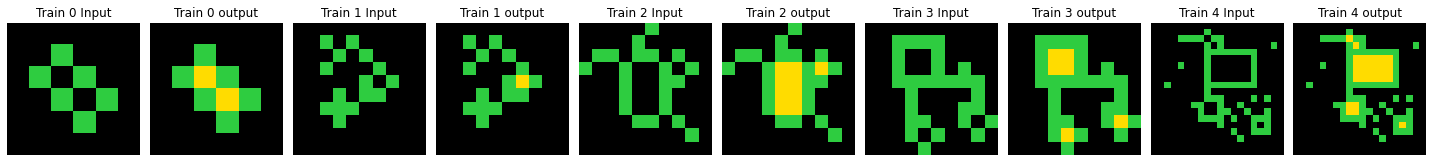

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {9, 5, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {5, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {9, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {15}, {0})]]]
test_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {9, 5, 15}, {0})]]
this_test_objective[x]:  [('nonbg-1', 'nil', 'direct')]
global_objective[y]:  [('nonbg-1', 'nil', 'direct')]
True
True
this_test_objective[x]:  [('nonbg-1', 'nil', 'direct')]
global_objective[y]:  [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 7], (1, {1, 3}), (4, {168, 506, 90}), (5, {1}), (7, {1})]
True
False
this_test_objective[x]:  [('nonbg0', 'nonbg0', 'direct')]
global_objective[y]:  [('nonbg-1', 'nil', 'direct')]
True
False
this_test_objective[x]:  [('nonbg0', 'nonbg0', 'direct')]
global_objective[y]:  

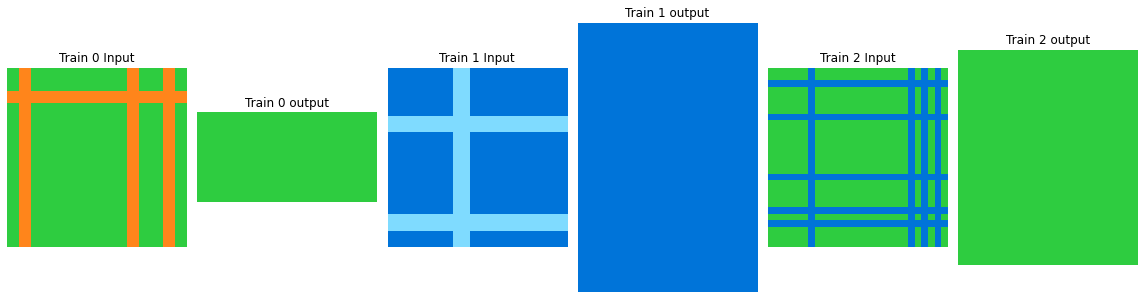

obj_staus:  obd
running_objective:  [[[('nonbg-1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 7], (1, {1, 3}), (4, {168, 506, 90}), (5, {1}), (7, {1})]], [[('nonbg-1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 6, 7], (1, {1}), (4, {90}), (5, {1}), (6, {1, 3}), (7, {1})]], [[('nonbg-1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 7], (1, {3}), (4, {506}), (5, {1}), (7, {1})]]]
test_objective:  [[[('nonbg-1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct')]]]
test_running_objective:  [[('nonbg-1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 7], (1, {1, 3}), (4, {168, 506, 90}), (5, {1}), (7, {1})]]
this_test_objective[x]:  [('nonbg1', 'nil', 'direct')]
global_objective[y]:  [('nonbg2', 'nil', 'direct')]
True
False
this_test_objective[x]:  [('nonbg1', 'nil', 'direct')]
global_objective[y]:  [('bg', 'bg', 'direct')]
True
False
this_test_objective[x]:  [('nonbg1', 'nil', 'direct')]
global_objective[y]:  [('nonbg0p

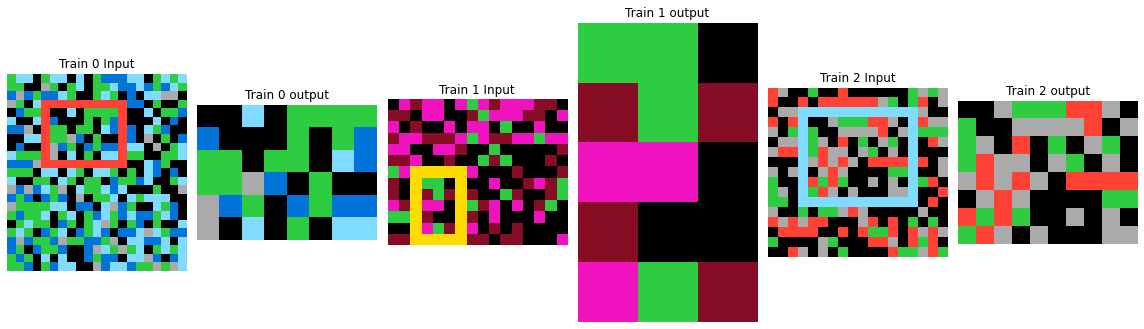

obj_staus:  irr
running_objective:  [[[('nonbg2', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]], [[('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_objective:  [[[('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]
this_test_objective[x]:  [('

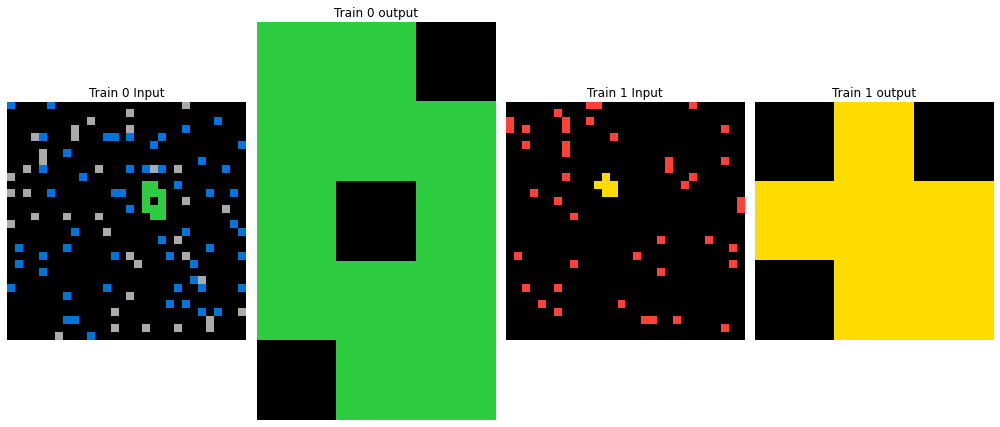

obj_staus:  red
running_objective:  [[[('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0', 'nonbg0', 'direct')]], [[('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0', 'nonbg0', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')]]
this_test_objective[x]:  [('bg', 'bg', 'direct')]
global_objective[y]:  [('bg', 'bg', 'direct')]
True
True
this_test_objective[x]:  [('bg', 'bg', 'direct')]
global_objective[y]:  [('nonbg0pr', 'nonbg0pr', 'direct')]
True
False
this_test_objective[x]:  [('bg', 'bg', 'direct')]
global_objective[y]:  [('nonbg1', 'nonbg1', 'direct')]
True
False
this_test_objective[x]:  [('bg', 'bg', 'direct')]
global_objective[y]:  [('nonbg2', 'nonbg2', 'direct')]
True
Fal

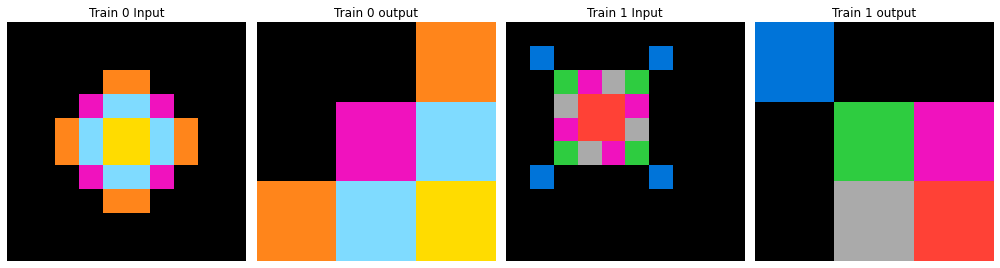

obj_staus:  red
running_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]
this_test_objective[x]:  [('bg', 'bg', 'direct')]
global_objective[y]:  [('nonbg1pr', 'nil', 'direct')]
True
False
this_test_objective[x]:  [('bg', 'bg', 'direct')]
global_objective

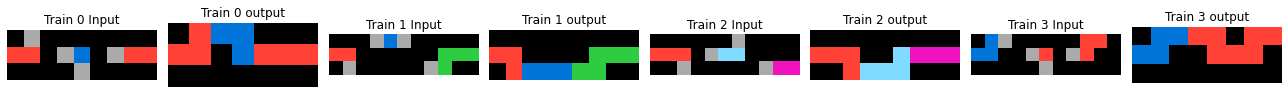

obj_staus:  red
running_objective:  [[[('nonbg1pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nonbg1pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg1pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg1pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3',

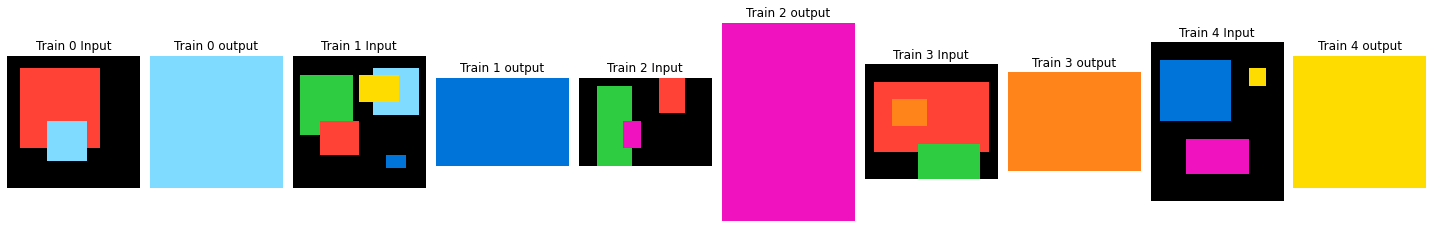

obj_staus:  red
running_objective:  [[[('nonbg-1pr', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {8}), (4, {9}), (5, {0})]], [[('nonbg-1pr', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nil', 'direct')], [('nonbg4', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {1, 4, 6, 7, 8}), (4, {9, 4, 12, 6}), (5, {0})]], [[('nonbg-1pr', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {6}), (4, {6}), (5, {0})]], [[('nonbg-1pr', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {7}), (4, {12}), (5, {0})]], [[('nonbg-1pr', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {4}), (4, {4}), (5, {0})]]]
test_objective:  [[[('nonbg-1pr', 'nil', 'di

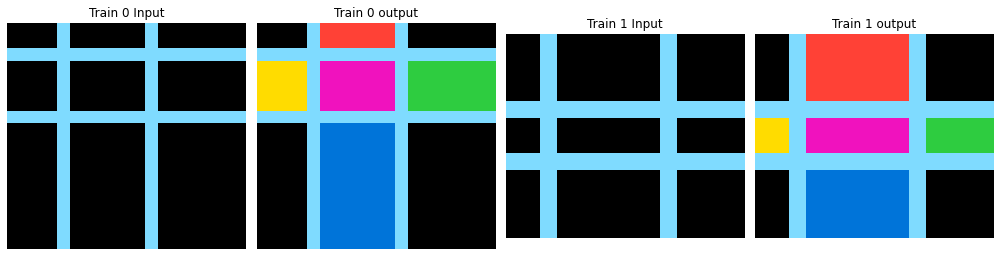

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {8, 9, 5, 7}, {4})], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {8, 9, 5, 7}, {2})], [('bg', 'bg'), ('bg', 'nonbg2pr'), [6], (6, {8, 9, 5, 7}, {1})], [('bg', 'bg'), ('bg', 'nonbg3pr'), [6], (6, {8, 9, 5, 7}, {3})], [('bg', 'bg'), ('bg', 'nonbg4pr'), [6], (6, {8, 9, 5, 7}, {0})], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [2, 6], (2, {8, 9, 10, 11, 12, 13, 14, 15, 16, 17}, {0, 1, 2, 3}), (6, {4}, {2})], [('bg', 'nonbg0pr'), ('bg', 'nonbg2pr'), [2, 6], (2, {8, 9, 10, 11, 12, 13, 14, 15, 16, 17}, {3, 4, 5, 6}), (6, {4}, {1})], [('bg', 'nonbg0pr'), ('bg', 'nonbg3pr'), [2, 6], (2, {8, 9, 10, 11, 12, 13, 14, 15, 16, 17}, {3, 4, 5, 6}), (6, {4}, {3})], [('bg', 'nonbg0pr'), ('bg', 'nonbg4pr'), [2, 6], (2, {8, 9, 10, 11, 12, 13, 14, 15, 16, 17}, {3, 4, 5, 6}), (6, {4}, {0})], [('bg', 'nonbg1pr'), ('bg', 'nonbg2pr'), [6], (6, {2}, {1})], [('bg', 'nonbg1pr'), ('bg', 'nonbg3pr'), [6], (6, {2}, {3})], [('bg', 'nonbg1pr

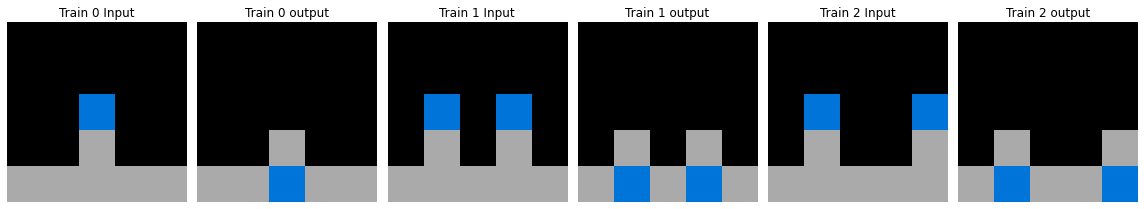

obj_staus:  obd
running_objective:  [[[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {11, 15}, {9, 4})]], [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {11, 15}, {4})]], [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {11, 15}, {9, 4})]]]
test_objective:  [[[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr')]]]
test_running_objective:  [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {11, 15}, {9, 4})]]
this_test_objective[x]:  [('bg', 'bg'), ('bg', 'nonbg0pr')]
global_objective[y]:  [('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]
True
True
[0]
[]
94


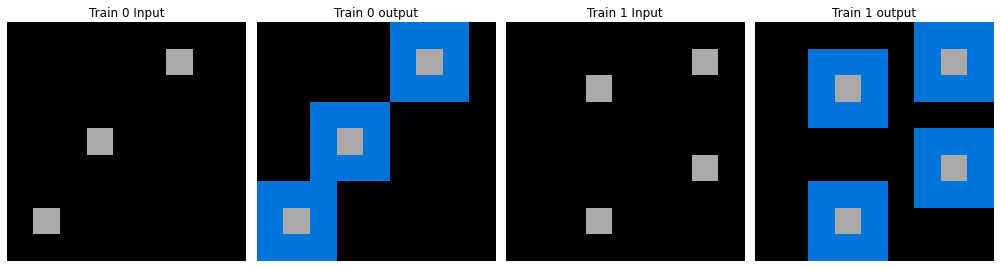

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]]]
test_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]]
this_test_objective[x]:  [('nonbg-1pr', 'nonbg-1pr', 'direct')]
global_objective[y]:  [('nonbg-1pr', 'nonbg-1pr', 'direct')]
True
True
this_test_objective[x]:  [('nonbg-1pr', 'nonbg-1pr', 'direct')]
global_objective[y]:  [('nonbg0pr', 'nonbg0pr', 'direct')]
True
False
this_test_objective[x]:  [('nonbg-1pr', 'nonbg-1pr', 'direct')]
global_objective[y]:  [('nonbg1', 'nonbg1', 'direct')]
True
False
this_test_objective[x]:  [('nonbg-1pr', 'nonbg-1pr', 'direct')]
global_objective[y]:  [('nonbg2', 'nonbg2', 'direct')]
True
False
this_test_objective[x]:  [('nonbg-1pr', 'nonbg-1pr', 'direct')]
global_objective[y]:  [('nonbg3', 'nonbg3', 'direct')]
True
False
this_test_objective[x]:  [('nonbg-1pr', 'nonbg-1pr

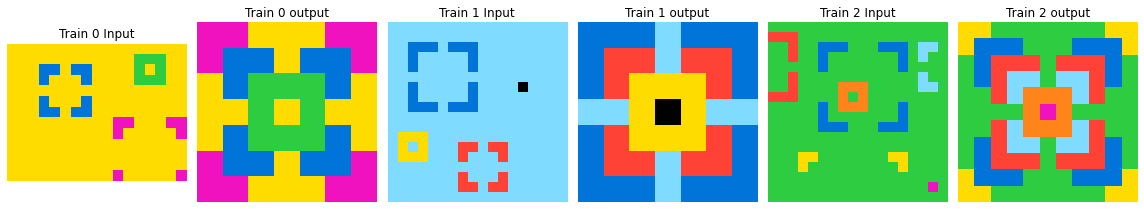

obj_staus:  red
running_objective:  [[[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]]]
test_objective:  [[[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_running_objective:  [[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2',

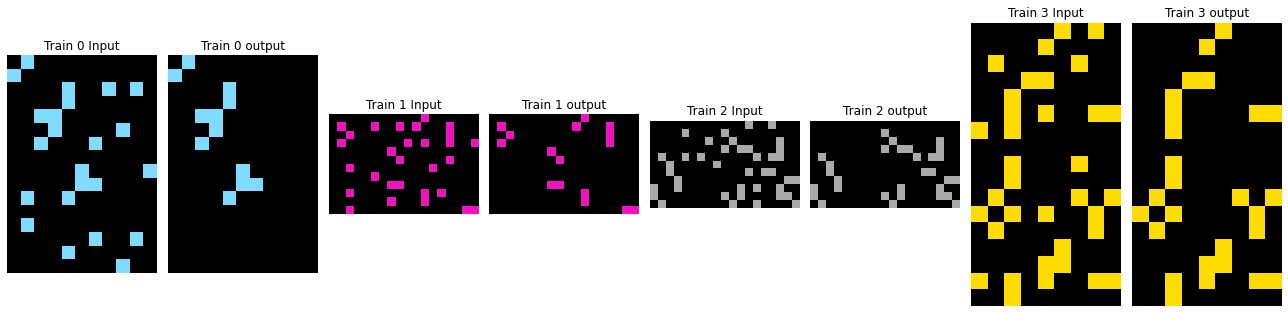

obj_staus:  obd
running_objective:  [[[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [7], (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [7], (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [7], (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [7], (7, {2}, {1})]]]
test_objective:  [[[('nonbg0', 'nonbg0'), ('nonbg0', 'bg')]]]
test_running_objective:  [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [7], (7, {2}, {1})]]
this_test_objective[x]:  [('nonbg0', 'nonbg0'), ('nonbg0', 'bg')]
global_objective[y]:  [('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]
True
True
this_test_objective[x]:  [('nonbg0', 'nonbg0'), ('nonbg0', 'bg')]
global_objective[y]:  [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]
True
False
this_test_objective[x]:  [('nonbg0', 'nonbg0'), ('nonbg0', 'bg')]
global_objective[y]:  [('nonbg2', 'nonbg2'), ('nonbg2', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]
True
False
this_test_objective[x

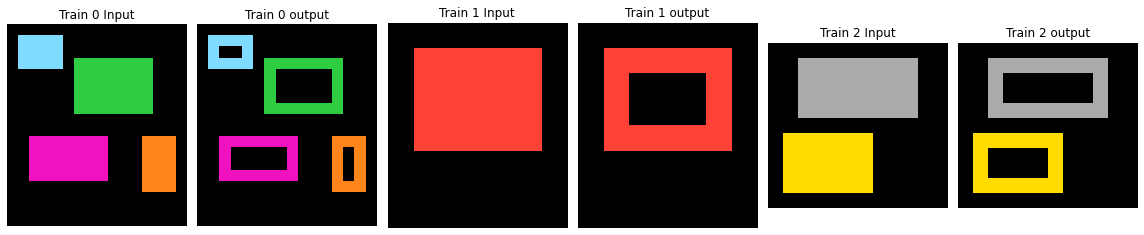

obj_staus:  red
running_objective:  [[[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg2', 'nonbg2'), ('nonbg2', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg3', 'nonbg3'), ('nonbg3', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]]]
test_objective:  [[[('nonbg0', 'nonbg0'), ('nonbg0', 'bg')], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg')], [('nonbg2', 'nonbg2'), ('nonbg2', 'bg')], [('nonbg3', 'nonbg3'), ('nonbg3', 'bg')], [('nonbg4', 'nonbg4'), ('nonbg4', 'bg')]]]
test_running_objective:  [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [6, 7], (6, 

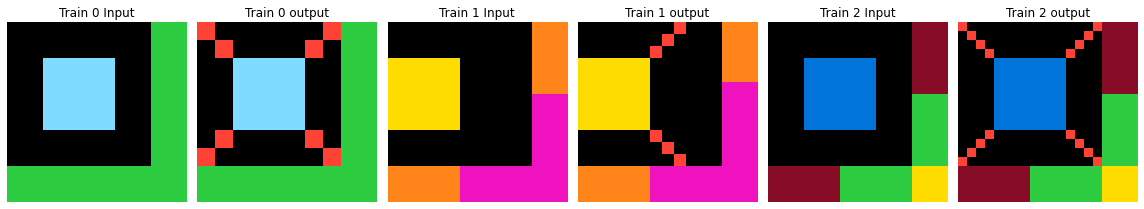

obj_staus:  red
running_objective:  [[[('nil', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nil', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nil', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nil', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nil', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]
this_test_objective[x]:  [('nonbg0pr',

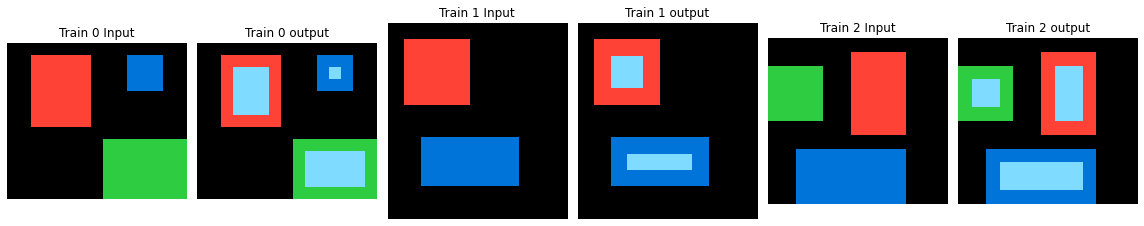

obj_staus:  red
running_objective:  [[[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr'), [6], (6, {4, 15}, {0})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg3', 'nonbg3'), ('nonbg3', 'nonbg2pr'), [6], (6, {1, 3, 4, 9, 15}, {0})]], [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]], [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr'), [6], (6, {4, 15}, {0})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg3', 'nonbg3'), ('nonbg3', 'nonbg2pr'), [6], (6, {3, 15}, {0})]]]
test_objective:  [[[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr')], [('nonbg3', 'nonbg3'), ('nonbg3', 'nonbg2pr')]]]
test_running_objective:  [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr'), [6], (6, {4, 15}, {0}

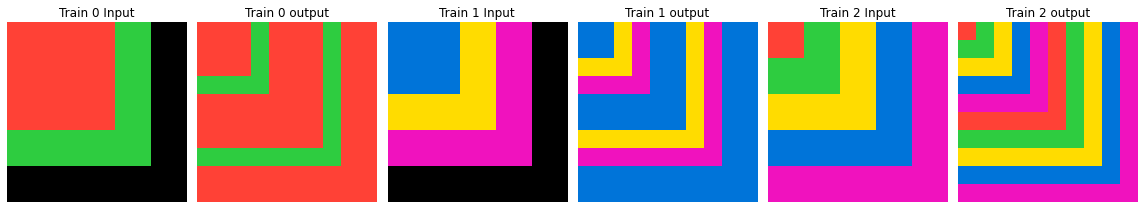

obj_staus:  irr
running_objective:  [[[('nonbg0', 'nil', 'direct')], [('nonbg-1', 'nonbg-1', 'direct')], [('nonbg1', 'nonbg1', 'direct')]], [[('nonbg2', 'nil', 'direct')], [('nonbg-1', 'nonbg-1', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]], [[('nonbg-1', 'nonbg-1', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_objective:  [[[('nonbg0', 'nil', 'direct')], [('nonbg-1', 'nonbg-1', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]]
test_running_objective:  [[('nonbg-1', 'nonbg-1', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]
this_test_objective[x]:  [('bg', 'bg'), ('bg', 'nonbg0pr')]
global_objective[y]:  [('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]
True
True
this_test_objective[x]:  [('bg', 'bg'), ('bg', 'nonbg0pr')]
global_objective[y]:  [

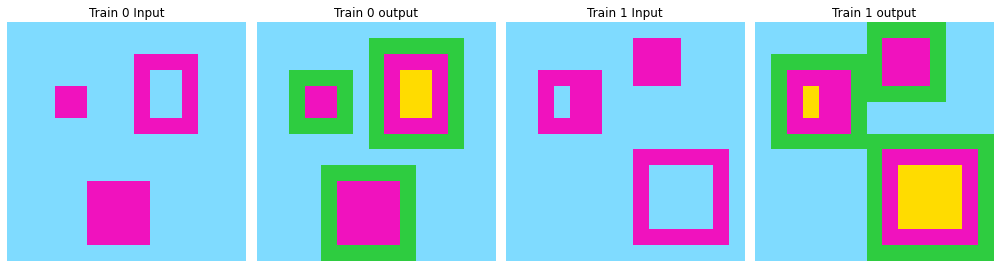

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]]]
test_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1pr')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]]
this_test_objective[x]:  [('bg', 'bg', 'direct')]
global_objective[y]:  [('nonbg0pr', 'nil', 'direct')]
True
False
this_test_objective[x]:  [('bg', 'bg', 'direct')]
global_objective[y]:  [('bg', 'bg', 'direct')]
True
True
this_test_objective[x]:  [('bg', 'bg', 'direct')]

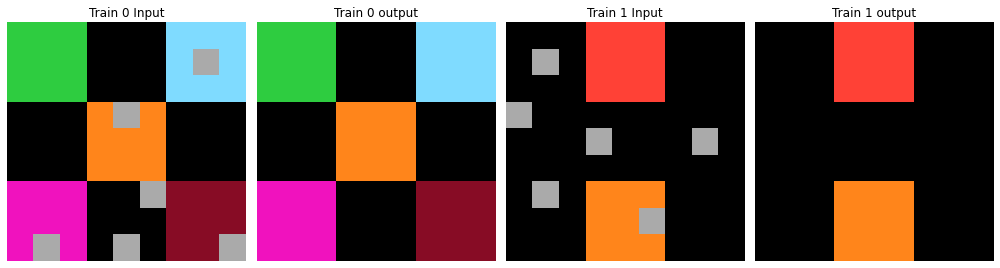

obj_staus:  red
running_objective:  [[[('nonbg0pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]], [[('nonbg0pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0pr', 'nil', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nonbg0pr', 'nil', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]]
this_test_objective[x]:  [('bg', 'nil', 'direct')]
global_objective[y]:  [('bg', 'nil', 'direct')]
True
True
this_tes

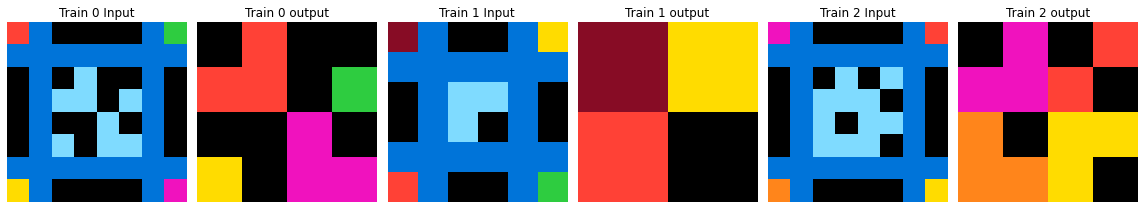

obj_staus:  irr
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg4', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg5', 'nonbg5', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonb

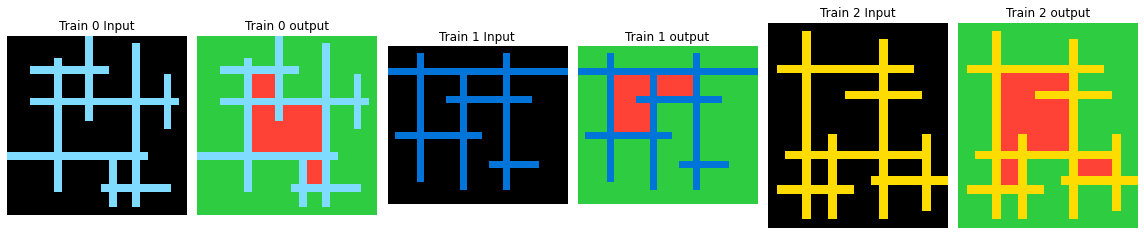

obj_staus:  obd
running_objective:  [[[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {0}, {13, 11, 5, 15})]], [[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {0}, {11, 13})]], [[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {0}, {15})]]]
test_objective:  [[[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr')]]]
test_running_objective:  [[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {0}, {13, 11, 5, 15})]]
this_test_objective[x]:  [('bg', 'nil', 'direct')]
global_objective[y]:  [('bg', 'nil', 'direct')]
True
True
this_test_objective[x]:  [('bg', 'nil', 'direct')]
global_objective[y]:  [('nonbg3pr', 'nil', 'direct')]
True
False
this_test_objective[x]:  [('bg', 'nil', 'direct')]
global_objective[y]:  [('nonbg0pr', 'nonbg0pr', 'direct')]
True
False
this_test_objective[x]:  [('bg', 'nil', 'direct')]
global_objective[y]:  [('nonbg1pr', 'nonbg1pr', 'direct')]
True
False
this_test_objective[x]:  [('bg', 'nil', 'direct')]
global_objective[y]:  [('nonbg2pr', 'nonbg2pr', 'direct')]
True
False
thi

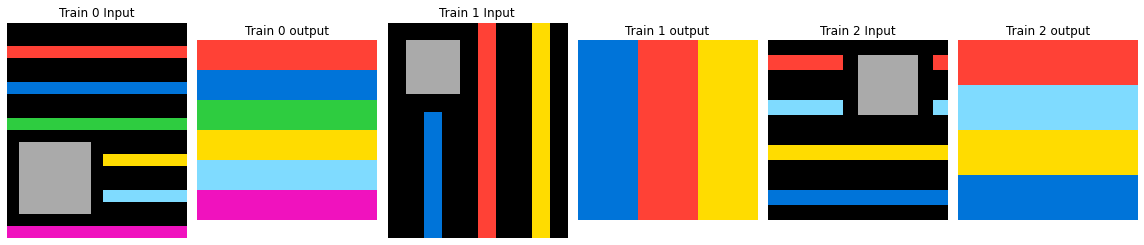

obj_staus:  red
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')], [('nonbg6', 'nonbg6', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')], [('nonbg6', 'nonbg6', 'direct')]]]
tes

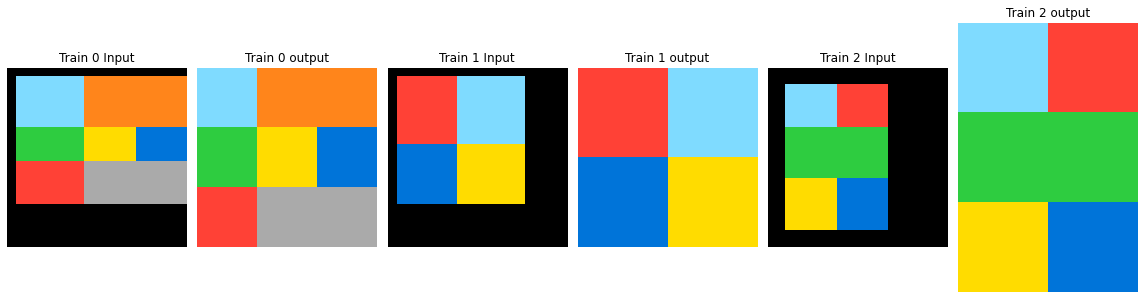

obj_staus:  red
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nonbg3pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')], [('nonbg6', 'nonbg6', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nonbg3pr', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nonbg3pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nonbg3pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_running_objective:  [[('bg', 'nil', 'direct')]

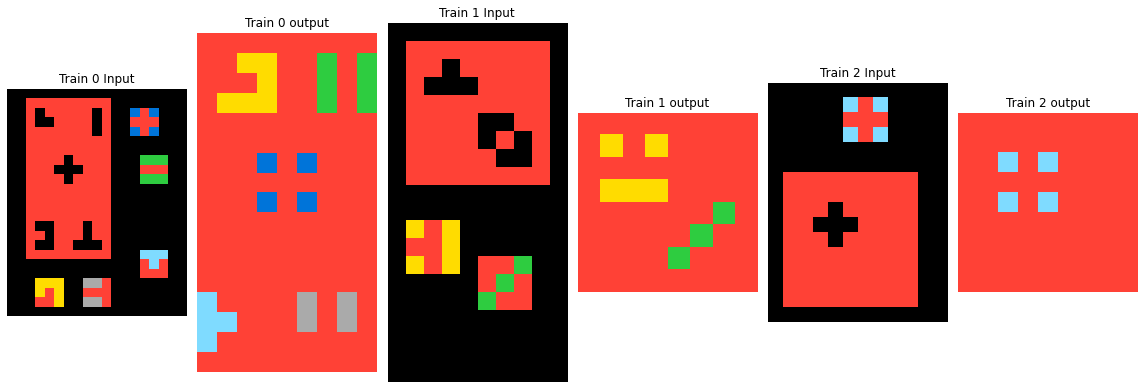

obj_staus:  red
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_running_objective:  [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]]
[]
[]
23

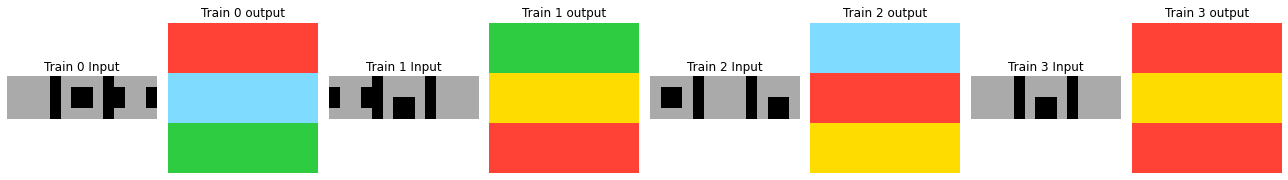

obj_staus:  red
running_objective:  [[[('bg', 'nonbg1pr', 'direct')], [('bg', 'nonbg2', 'direct')], [('bg', 'nonbg3', 'direct')], [('nonbg0pr', 'nonbg1pr', 'direct')], [('nonbg0pr', 'nonbg2', 'direct')], [('nonbg0pr', 'nonbg3', 'direct')]], [[('bg', 'nonbg1pr', 'direct')], [('bg', 'nonbg2', 'direct')], [('bg', 'nonbg3', 'direct')], [('nonbg0pr', 'nonbg1pr', 'direct')], [('nonbg0pr', 'nonbg2', 'direct')], [('nonbg0pr', 'nonbg3', 'direct')]], [[('bg', 'nonbg1pr', 'direct')], [('bg', 'nonbg2', 'direct')], [('bg', 'nonbg3', 'direct')], [('nonbg0pr', 'nonbg1pr', 'direct')], [('nonbg0pr', 'nonbg2', 'direct')], [('nonbg0pr', 'nonbg3', 'direct')]], [[('bg', 'nonbg1pr', 'direct')], [('bg', 'nonbg2', 'direct')], [('nonbg0pr', 'nonbg1pr', 'direct')], [('nonbg0pr', 'nonbg2', 'direct')]]]
test_objective:  [[]]
test_running_objective:  [[('bg', 'nonbg1pr', 'direct')], [('bg', 'nonbg2', 'direct')], [('bg', 'nonbg3', 'direct')], [('nonbg0pr', 'nonbg1pr', 'direct')], [('nonbg0pr', 'nonbg2', 'direct')],

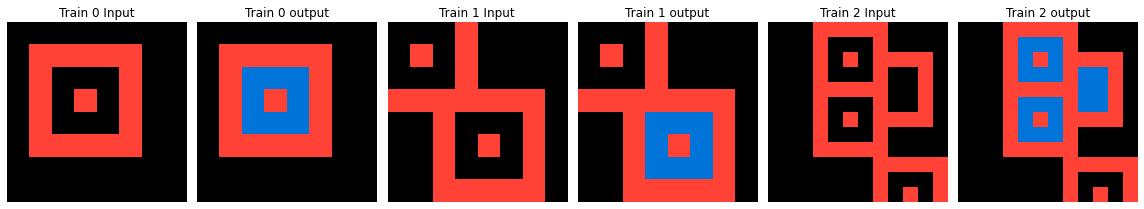

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {4, 5, 7, 8, 12, 14, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {8, 5, 14}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {12, 4, 7}, {0})]]]
test_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {4, 5, 7, 8, 12, 14, 15}, {0})]]
this_test_objective[x]:  [('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr')]
global_objective[y]:  [('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr'), [3], (3, {0, 2, 4, 6}, {1, 3, 5, 7})]
True
True
[0]
[]
251


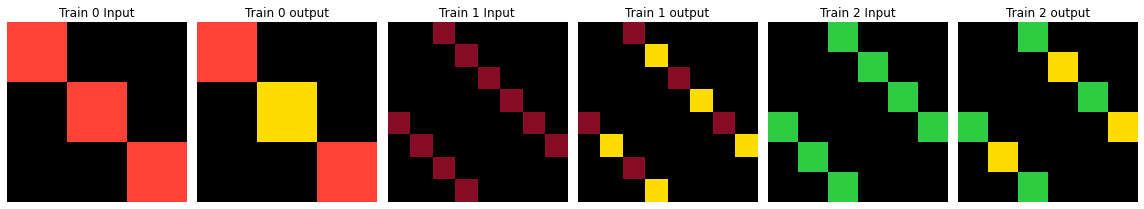

obj_staus:  obd
running_objective:  [[[('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr'), [3], (3, {0, 2, 4, 6}, {1, 3, 5, 7})]], [[('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr'), [2, 3], (2, {0, 2, 4, 6}, {1, 3, 5, 7}), (3, {0, 2, 4, 6}, {1, 3, 5, 7})]], [[('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr'), [3], (3, {0, 2, 4}, {1, 3, 5})]]]
test_objective:  [[[('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr')]]]
test_running_objective:  [[('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr'), [3], (3, {0, 2, 4, 6}, {1, 3, 5, 7})]]
this_test_objective[x]:  [('bg', 'nil', 'direct')]
global_objective[y]:  [('bg', 'nonbg2', 'direct')]
True
False
this_test_objective[x]:  [('bg', 'nil', 'direct')]
global_objective[y]:  [('nonbg0', 'nonbg0', 'direct')]
True
False
this_test_objective[x]:  [('bg', 'nil', 'direct')]
global_objective[y]:  [('nonbg1', 'nonbg1', 'direct')]
True
False
this_test_objective[x]:  [('nonbg0', 'nonbg0', 'direct')]
global_objective[y]:  [('bg', 'nonbg2', 'direct')]
True
False
this_test_objective[x]

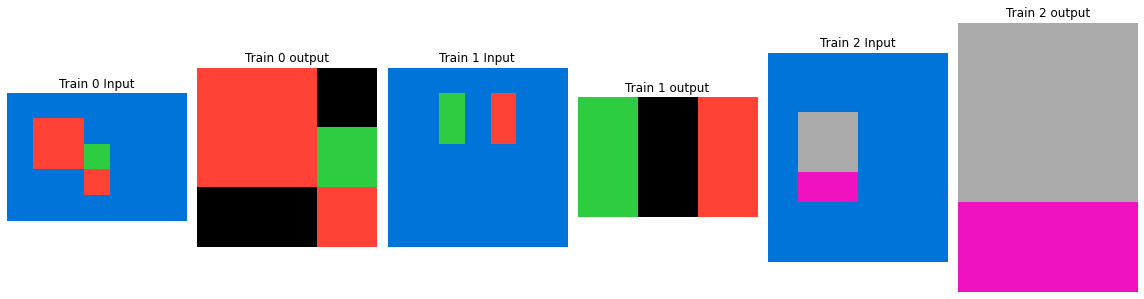

obj_staus:  irr
running_objective:  [[[('bg', 'nonbg2', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]], [[('bg', 'nonbg2', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]]
test_running_objective:  [[('bg', 'nonbg2', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]
this_test_objective[x]:  [('bg', 'bg', 'direct')]
global_objective[y]:  [('nonbg2pr', 'nil', 'direct')]
True
False
this_test_objective[x]:  [('bg', 'bg', 'direct')]
global_objective[y]:  [('bg', 'bg', 'direct')]
True
True
this_test_objective[x]:  [('bg', 'bg', 'direct')]
global_objective[y]:  [('nonbg0pr', 'nonbg0pr', 'direct')]
True
False
this_test_objective[x]:  [('bg', 'bg', 'direct')]
global_objective[y]:  [('nonbg1pr',

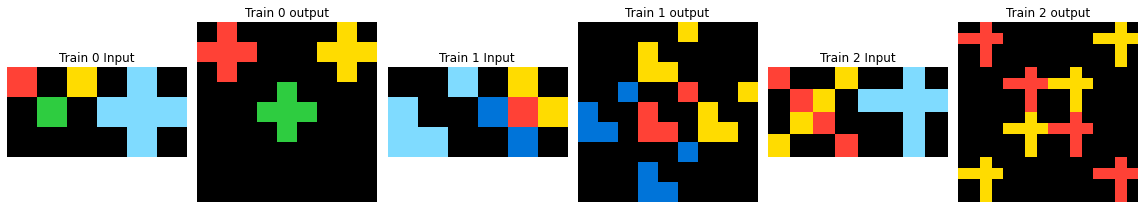

obj_staus:  red
running_objective:  [[[('nonbg2pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg2pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg2pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nil', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nil', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]
this_test_objective[x]:  [('bg', 'nil', 'direct')]
global_objective[y]:  [('bg', 'nil', 'direct')]
T

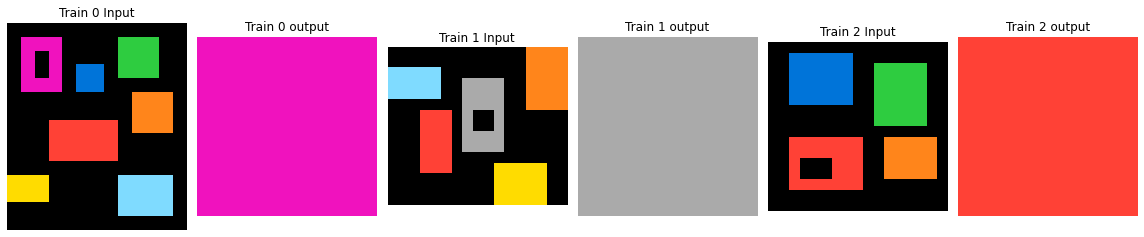

obj_staus:  irr
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nil', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nil', 'direct')], [('nonbg4', 'nil', 'direct')], [('nonbg6', 'nil', 'direct')], [('nonbg5', 'nonbg5', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nil', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nil', 'direct')], [('nonbg4', 'nonbg4', 'direct'), [1], (1, {5})]], [[('bg', 'nil', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct'), [1, 4, 5], (1, {2}), (4, {29}), (5, {1})]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nil', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nil', 'direct')], [('nonbg4', 'nil', 'direct')], [('nonbg5', 'nonbg5', 'direct')]]]
test_running_objective:  [[('bg', 'nil', 'direct')], [('nonb

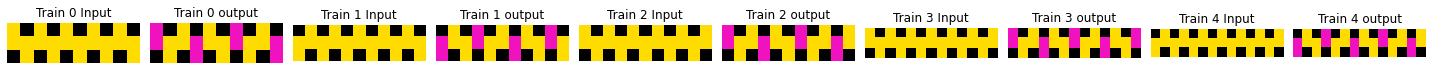

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10, 11, 13}, {0, 3, 6, 9, 12})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10}, {0, 9, 3, 6})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10}, {0, 9, 3, 6})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10, 11}, {0, 3, 6, 9, 12})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10, 11, 13}, {0, 3, 6, 9, 12})]]]
test_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10, 11, 13}, {0, 3, 6, 9, 12})]]
this_test_objective[x]:  [('nonbg1', 'nonbg1', 'direct')]
global_objective[y]:  [('nonbg1', 'nonbg1', 'direct')]
True
True
this_test_objective[x]:  [('nonbg1', 'nonbg1', 'direct')]
global_objective[y]:  [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [6], (6, {5, 7, 8, 9, 12, 14}, {0})]
True
False
this_test_objective[x]:  [(

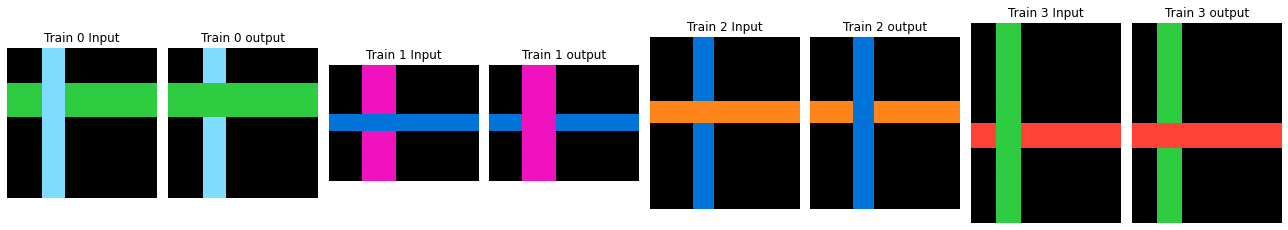

obj_staus:  irr
running_objective:  [[[('nonbg1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [6], (6, {5, 7, 8, 9, 12, 14}, {0})]], [[('nonbg1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [3, 6], (3, {0, 1, 4, 5, 6, 7, 8}, {2, 3}), (6, {12, 14}, {0})]], [[('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0'), [3, 6], (3, {0, 1, 3, 4, 5, 6}, {2}), (6, {12, 14}, {0})]], [[('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0'), [2, 6], (2, {0, 1, 2, 3, 5, 6, 7}, {4}), (6, {11, 13}, {0})]]]
test_objective:  [[[('nonbg1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1')]]]
test_running_objective:  [[('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [6], (6, {5, 7, 8, 9, 12, 14}, {0})], [('nonbg1', 'nonbg1', 'direct')]]
this_test_objective[x]:  [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr')]
global_objective[y]:  [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {3, 4, 15}

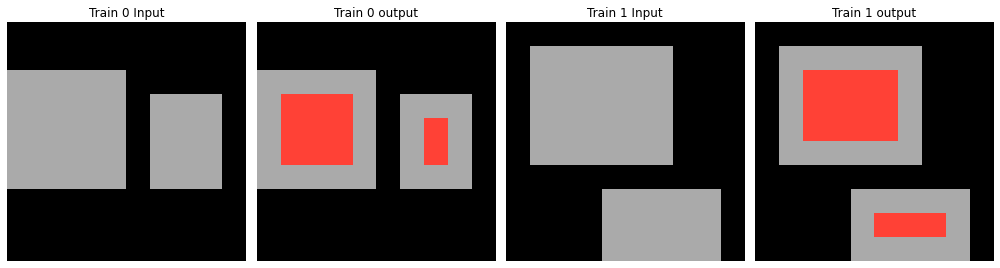

obj_staus:  obd
running_objective:  [[[('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {3, 4, 15}, {0})]], [[('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {4, 15}, {0})]]]
test_objective:  [[[('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr')]]]
test_running_objective:  [[('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {3, 4, 15}, {0})]]
this_test_objective[x]:  [('nonbg-1pr', 'nonbg0', 'direct')]
global_objective[y]:  [('nonbg-1pr', 'nonbg0', 'direct')]
True
True
this_test_objective[x]:  [('nonbg-1pr', 'nonbg0', 'direct')]
global_objective[y]:  [('nonbg0', 'nonbg1', 'direct')]
True
False
this_test_objective[x]:  [('nonbg-1pr', 'nonbg0', 'direct')]
global_objective[y]:  [('nonbg1', 'nonbg-1pr', 'direct')]
True
False
[0]
[]
this_test_objective[x]:  [('nonbg-1pr', 'nonbg0', 'direct')]
global_objective[y]:  [('nonbg-1pr', 'nonbg0', 'direct')]
True
True
this_test_objective[x]:  [('nonbg-1pr', 'nonbg0', 'direct')]
global_objective[y]:  [('nonbg0', 'n

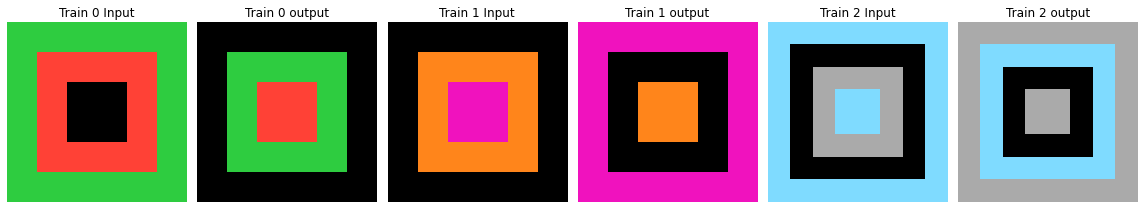

obj_staus:  irr
running_objective:  [[[('nonbg-1pr', 'nonbg0', 'direct')], [('nonbg0', 'nonbg1', 'direct')], [('nonbg1', 'nonbg-1pr', 'direct')]], [[('nonbg-1pr', 'nonbg0', 'direct')], [('nonbg0', 'nonbg1', 'direct')], [('nonbg1', 'nonbg-1pr', 'direct')]], [[('nonbg-1pr', 'nonbg1', 'direct')], [('nonbg0', 'nonbg-1pr', 'direct')], [('nonbg1', 'nonbg0', 'direct')]]]
test_objective:  [[[('nonbg-1pr', 'nonbg0', 'direct')]], [[('nonbg-1pr', 'nonbg0', 'direct')]]]
test_running_objective:  [[('nonbg-1pr', 'nonbg0', 'direct')], [('nonbg0', 'nonbg1', 'direct')], [('nonbg1', 'nonbg-1pr', 'direct')]]
this_test_objective[x]:  [('bg', 'bg', 'direct')]
global_objective[y]:  [('nonbg0', 'nil', 'direct')]
True
False
this_test_objective[x]:  [('bg', 'bg', 'direct')]
global_objective[y]:  [('nonbg1', 'nil', 'direct')]
True
False
this_test_objective[x]:  [('bg', 'bg', 'direct')]
global_objective[y]:  [('bg', 'bg', 'direct')]
True
True
this_test_objective[x]:  [('bg', 'bg', 'direct')]
global_objective[y]:

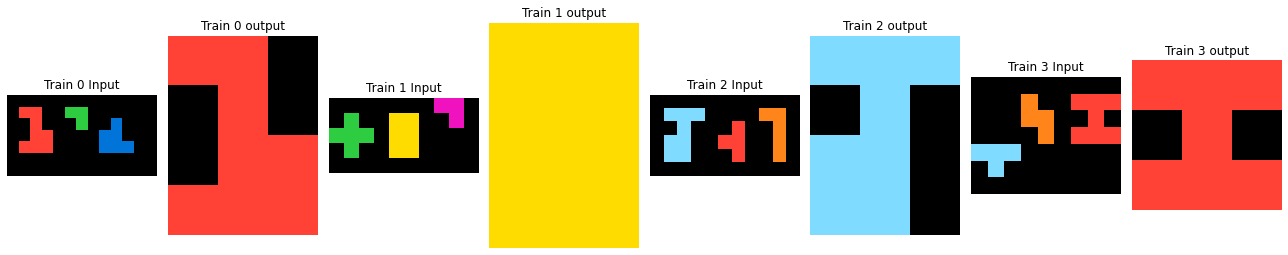

obj_staus:  irr
running_objective:  [[[('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]
this_test_objective[x]:  [('nonbg1pr', 'nonbg0pr', 'direct')]
global_objective[y]:  [('nonbg1pr', 'nonbg0pr', 'direct')]
True
True
this_test_objective[x]:  [('nonbg1pr', 'nonbg

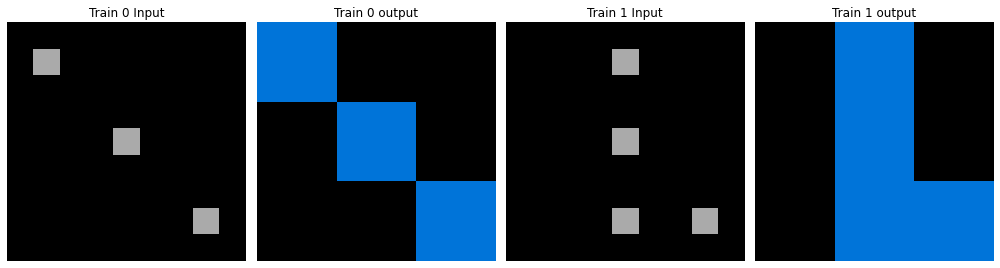

obj_staus:  obd
running_objective:  [[[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]]]
test_objective:  [[[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})], [('nonbg1pr', 'nonbg0pr', 'direct')]]
this_test_objective[x]:  [('nonbg1pr', 'bg', 'direct')]
global_objective[y]:  [('nonbg1pr', 'bg', 'direct')]
True
True
this_test_objective[x]:  [('nonbg1pr', 'bg', 'direct')]
global_objective[y]:  [('nonbg2', 'bg', 'direct')]
True
False
this_test_objective[x]:  [('nonbg1pr', 'bg', 'direct')]
global_objective[y]:  [('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'bg'), [3, 6], (3, {2}, {0}), (6, {7, 15}, {8})]
True
False
this_test_objective[x]:  [('nonbg1pr', 'bg', 'direct')]
global_objective[y]:  [('nonbg3', 'nonbg3'), ('nonbg3', 'bg'), [2, 3, 6], (2, {4}, {3}

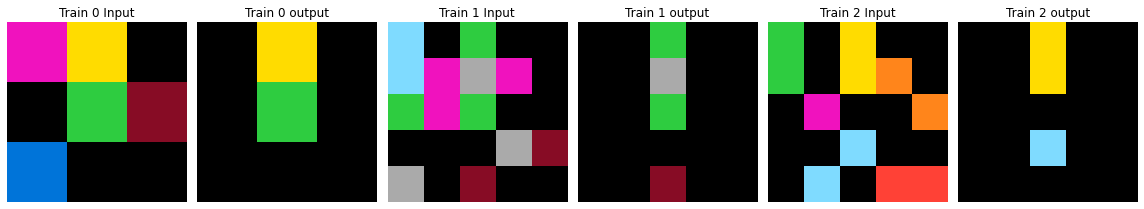

obj_staus:  irr
running_objective:  [[[('nonbg0pr', 'bg', 'direct')], [('nonbg1', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')]], [[('nonbg1pr', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'bg'), [3, 6], (3, {2}, {0}), (6, {7, 15}, {8})], [('nonbg3', 'nonbg3'), ('nonbg3', 'bg'), [2, 3, 6], (2, {4}, {3}), (3, {2}, {4}), (6, {13}, {14})], [('nonbg4', 'nonbg4'), ('nonbg4', 'bg'), [3, 6], (3, {2}, {0, 1, 3}), (6, {0, 13}, {8, 15})]], [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')], [('nonbg3', 'bg', 'direct')], [('nonbg4', 'nonbg4'), ('nonbg4', 'bg'), [2, 3, 6, 7], (2, {3}, {4}), (3, {2}, {1}), (6, {13}, {8}), (7, {4}, {2})]]]
test_objective:  [[[('nonbg1pr', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'bg')], [('nonbg3', 'nonbg3'), ('nonbg3', 'bg')], [('nonbg4', 'nonbg4'), ('nonbg4', 'bg')]]]
test_running_objective:  [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr'

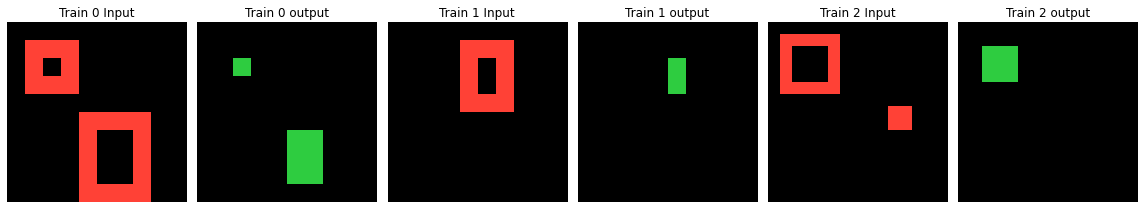

obj_staus:  obd
running_objective:  [[[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]], [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]], [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]]]
test_objective:  [[[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr')]], [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})], [('nonbg0pr', 'bg', 'direct')]]
this_test_objective[x]:  [('bg', 'nil', 'direct')]
global_objective[y]:  [('bg', 'nil', 'direct')]
True
True
this_test_objective[x]:  [('bg', 'nil', 'direct')]
global_objective[y]:  [('nonbg1', 'nil', 'direct')]
True
False
this_test_objective[x]:  [('bg', 'nil', 'direct')]
global_objective[y]:  [('nonbg1', 'nonbg1', 'direct')]
True
False
this_test_objective[x]:  [('nonbg1', 'nil', 'direct')]
global_objective[y]:  

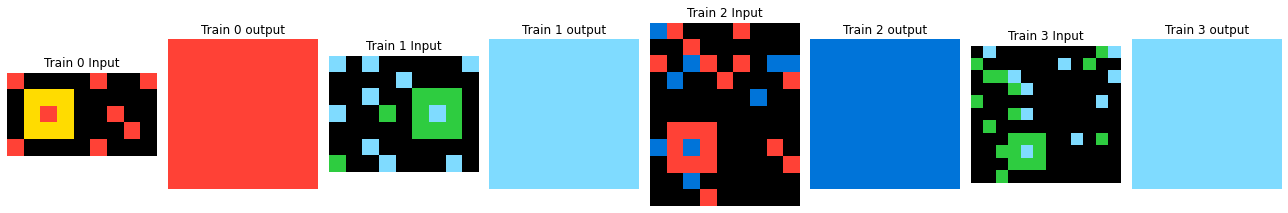

obj_staus:  irr
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct'), [1, 6], (1, {8}), (6, {0})]], [[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 6], (1, {1}), (4, {9}), (5, {0}), (6, {5})]], [[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {8}), (4, {10}), (5, {0})]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct')]]]
test_running_objective:  [[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]
this_test_objective[x]:  [('nonbg-1pr', 'nonbg-1pr', 'direct')]
global_objective[y]:  [('nonbg1pr', 'nil', 'direct')]
True
False
this_test_objective[x]:  [('nonbg-1pr', 'nonbg-1pr', 'direct')]
global_objective[y]:  [('nonbg-1pr', 'no

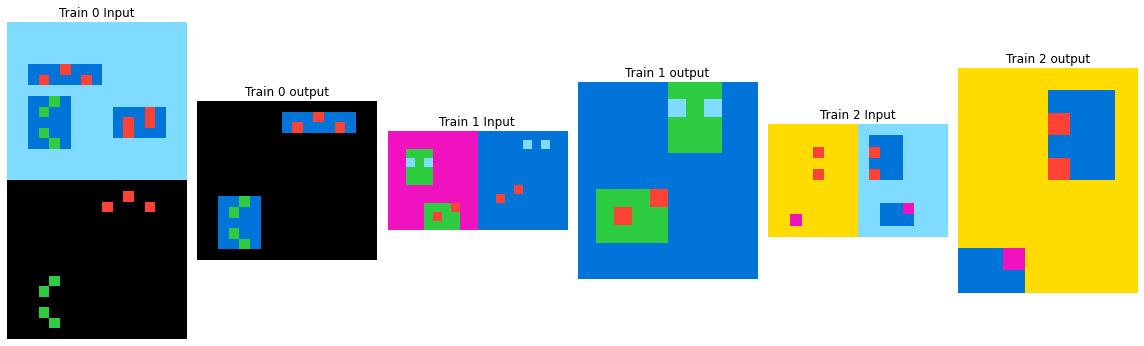

obj_staus:  irr
running_objective:  [[[('nonbg1pr', 'nil', 'direct')], [('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg3', 'nil', 'direct')], [('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nonbg1pr', 'nil', 'direct')], [('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_objective:  [[[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]]
test_running_objective:  [[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]
this_test_objective[x]:  [('nonbg-1', 'nonbg-1')

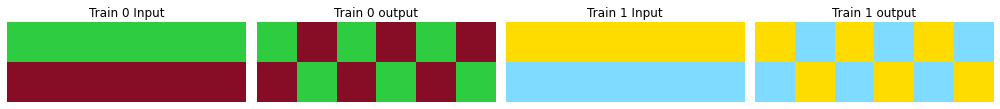

obj_staus:  obd
running_objective:  [[[('nonbg-1', 'nonbg-1'), ('nonbg-1', 'nonbg0'), [3], (3, {0, 2, 4}, {1, 3, 5})], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1'), [3], (3, {0, 2, 4}, {1, 3, 5})]], [[('nonbg-1', 'nonbg-1'), ('nonbg-1', 'nonbg0'), [3], (3, {0, 2, 4}, {1, 3, 5})], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1'), [3], (3, {0, 2, 4}, {1, 3, 5})]]]
test_objective:  [[[('nonbg-1', 'nonbg-1'), ('nonbg-1', 'nonbg0')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1')]]]
test_running_objective:  [[('nonbg-1', 'nonbg-1'), ('nonbg-1', 'nonbg0'), [3], (3, {0, 2, 4}, {1, 3, 5})], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1'), [3], (3, {0, 2, 4}, {1, 3, 5})]]
this_test_objective[x]:  [('nonbg1pr', 'nonbg0pr', 'direct')]
global_objective[y]:  [('bg', 'nonbg0pr', 'direct')]
True
False
this_test_objective[x]:  [('nonbg1pr', 'nonbg0pr', 'direct')]
global_objective[y]:  [('nonbg1pr', 'bg', 'direct')]
True
False
this_test_objective[x]:  [('nonbg1pr', 'nonbg0pr', 'direct')]
global_objective[y]:  [

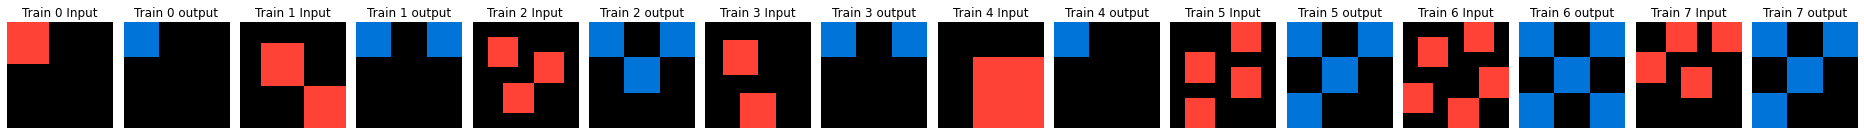

obj_staus:  irr
running_objective:  [[[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('bg', 'nonbg0pr', 'direct')], [('nonbg1pr', 'bg', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]]]
test_objective:  [[[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('bg', 'nonbg0pr', 'direct')], [('nonbg1pr', 'bg', 'direct')]]


In [36]:
for n in current_attention:
    this_task = previous_analysis[n]
    enforce_global_objective(this_task.test_objective, this_task.test_running_objective)
    print(n)
    plot_task(tt[n])
    print('obj_staus: ', this_task.objective_status)
    print('running_objective: ', this_task.running_objective)
    print('test_objective: ', this_task.test_objective)
    print('test_running_objective: ', sorted(this_task.test_running_objective))
    print('=========')

28


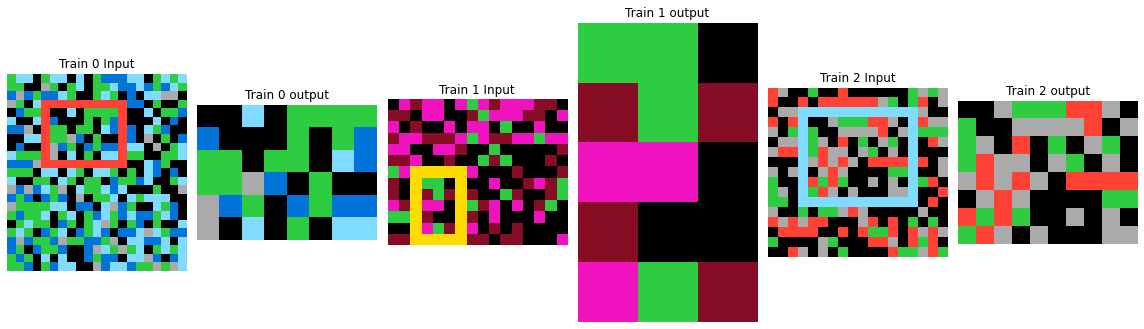

obj_staus:  irr
running_objective:  [[[('nonbg2', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]], [[('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_objective:  [[[('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]
38


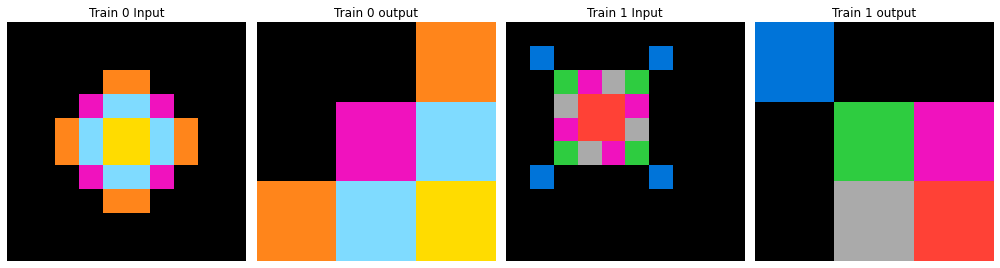

obj_staus:  red
running_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]
48


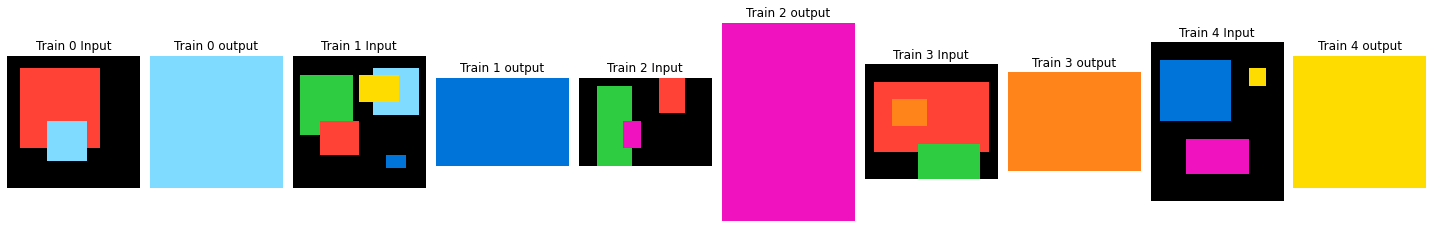

obj_staus:  red
running_objective:  [[[('nonbg-1pr', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {8}), (4, {9}), (5, {0})]], [[('nonbg-1pr', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nil', 'direct')], [('nonbg4', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {1, 4, 6, 7, 8}), (4, {9, 4, 12, 6}), (5, {0})]], [[('nonbg-1pr', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {6}), (4, {6}), (5, {0})]], [[('nonbg-1pr', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {7}), (4, {12}), (5, {0})]], [[('nonbg-1pr', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {4}), (4, {4}), (5, {0})]]]
test_objective:  [[[('nonbg-1pr', 'nil', 'di

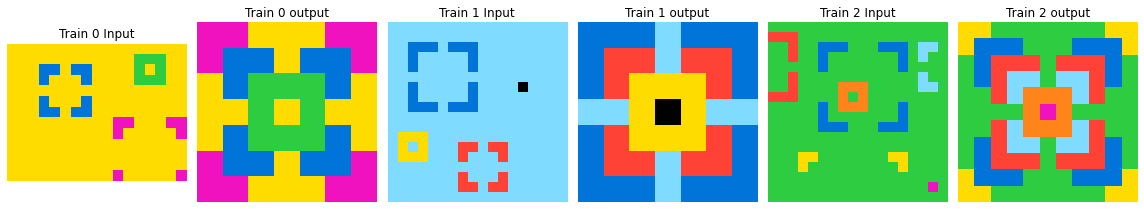

obj_staus:  red
running_objective:  [[[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]]]
test_objective:  [[[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_running_objective:  [[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2',

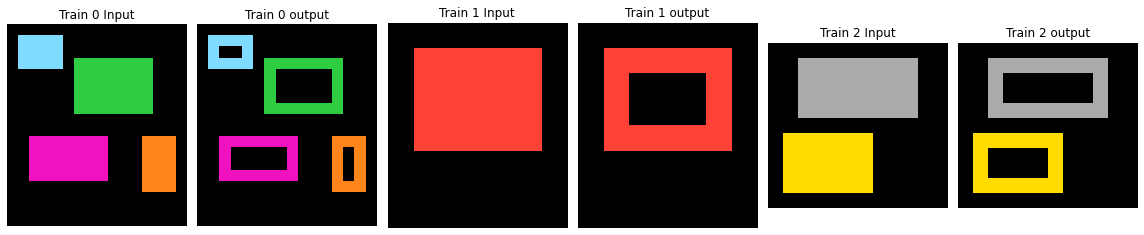

obj_staus:  red
running_objective:  [[[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg2', 'nonbg2'), ('nonbg2', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg3', 'nonbg3'), ('nonbg3', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]]]
test_objective:  [[[('nonbg0', 'nonbg0'), ('nonbg0', 'bg')], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg')], [('nonbg2', 'nonbg2'), ('nonbg2', 'bg')], [('nonbg3', 'nonbg3'), ('nonbg3', 'bg')], [('nonbg4', 'nonbg4'), ('nonbg4', 'bg')]]]
test_running_objective:  [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [6, 7], (6, 

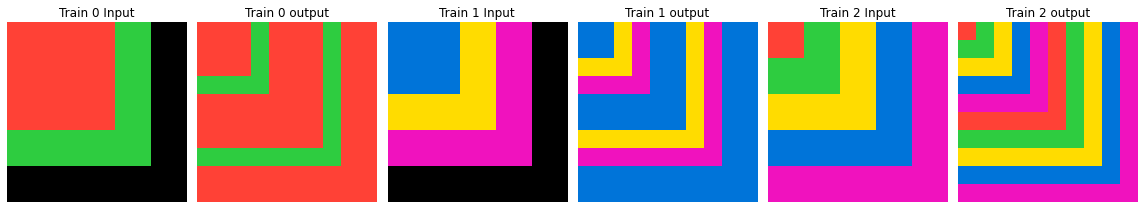

obj_staus:  irr
running_objective:  [[[('nonbg0', 'nil', 'direct')], [('nonbg-1', 'nonbg-1', 'direct')], [('nonbg1', 'nonbg1', 'direct')]], [[('nonbg2', 'nil', 'direct')], [('nonbg-1', 'nonbg-1', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]], [[('nonbg-1', 'nonbg-1', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_objective:  [[[('nonbg0', 'nil', 'direct')], [('nonbg-1', 'nonbg-1', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]]
test_running_objective:  [[('nonbg-1', 'nonbg-1', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]
129


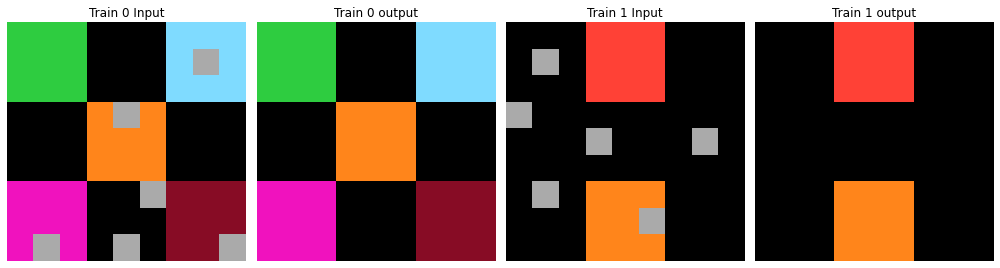

obj_staus:  red
running_objective:  [[[('nonbg0pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]], [[('nonbg0pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0pr', 'nil', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nonbg0pr', 'nil', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]]
217


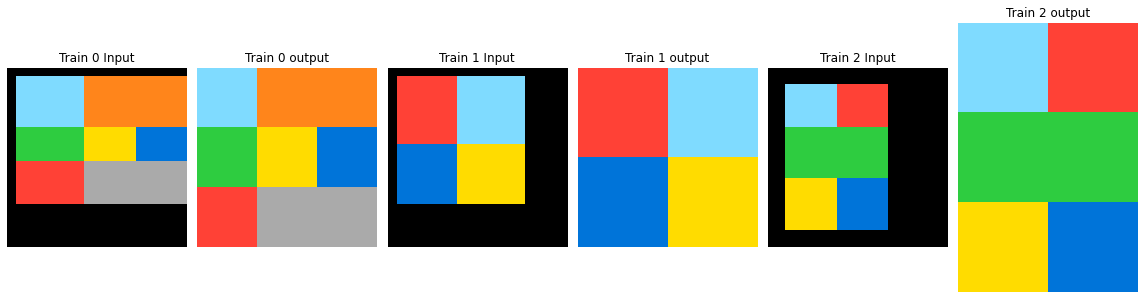

obj_staus:  red
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nonbg3pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')], [('nonbg6', 'nonbg6', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nonbg3pr', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nonbg3pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nonbg3pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_running_objective:  [[('bg', 'nil', 'direct')]

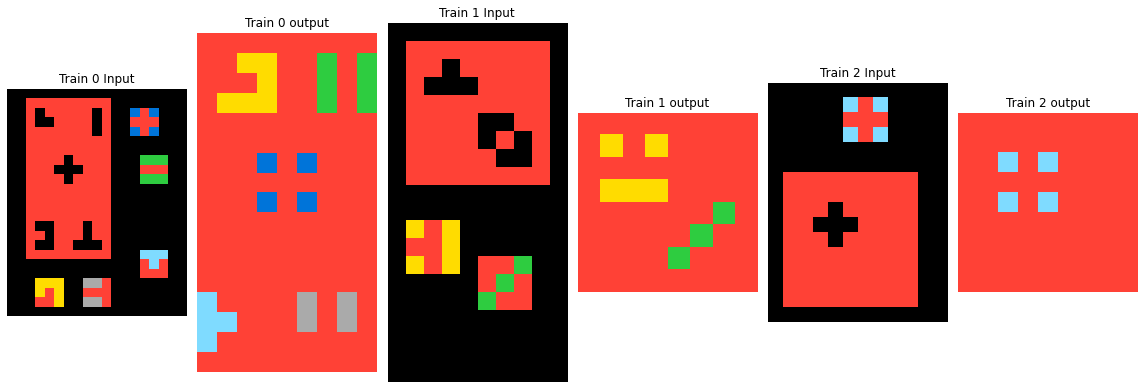

obj_staus:  red
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_running_objective:  [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]]
234


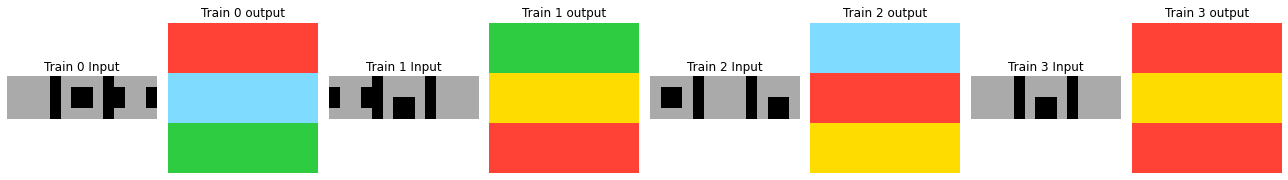

obj_staus:  red
running_objective:  [[[('bg', 'nonbg1pr', 'direct')], [('bg', 'nonbg2', 'direct')], [('bg', 'nonbg3', 'direct')], [('nonbg0pr', 'nonbg1pr', 'direct')], [('nonbg0pr', 'nonbg2', 'direct')], [('nonbg0pr', 'nonbg3', 'direct')]], [[('bg', 'nonbg1pr', 'direct')], [('bg', 'nonbg2', 'direct')], [('bg', 'nonbg3', 'direct')], [('nonbg0pr', 'nonbg1pr', 'direct')], [('nonbg0pr', 'nonbg2', 'direct')], [('nonbg0pr', 'nonbg3', 'direct')]], [[('bg', 'nonbg1pr', 'direct')], [('bg', 'nonbg2', 'direct')], [('bg', 'nonbg3', 'direct')], [('nonbg0pr', 'nonbg1pr', 'direct')], [('nonbg0pr', 'nonbg2', 'direct')], [('nonbg0pr', 'nonbg3', 'direct')]], [[('bg', 'nonbg1pr', 'direct')], [('bg', 'nonbg2', 'direct')], [('nonbg0pr', 'nonbg1pr', 'direct')], [('nonbg0pr', 'nonbg2', 'direct')]]]
test_objective:  [[]]
test_running_objective:  [[('bg', 'nonbg1pr', 'direct')], [('bg', 'nonbg2', 'direct')], [('bg', 'nonbg3', 'direct')], [('nonbg0pr', 'nonbg1pr', 'direct')], [('nonbg0pr', 'nonbg2', 'direct')],

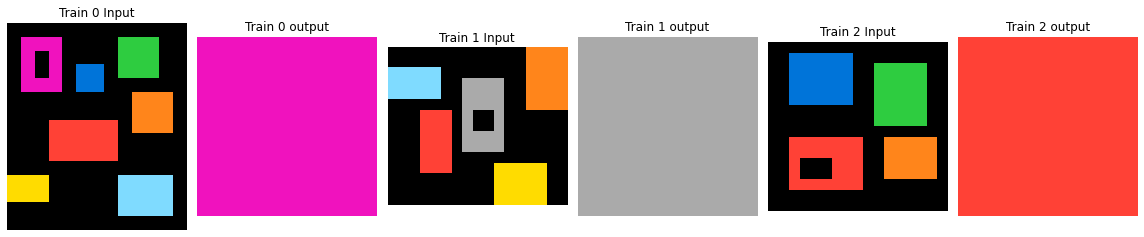

obj_staus:  irr
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nil', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nil', 'direct')], [('nonbg4', 'nil', 'direct')], [('nonbg6', 'nil', 'direct')], [('nonbg5', 'nonbg5', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nil', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nil', 'direct')], [('nonbg4', 'nonbg4', 'direct'), [1], (1, {5})]], [[('bg', 'nil', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct'), [1, 4, 5], (1, {2}), (4, {29}), (5, {1})]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nil', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nil', 'direct')], [('nonbg4', 'nil', 'direct')], [('nonbg5', 'nonbg5', 'direct')]]]
test_running_objective:  [[('bg', 'nil', 'direct')], [('nonb

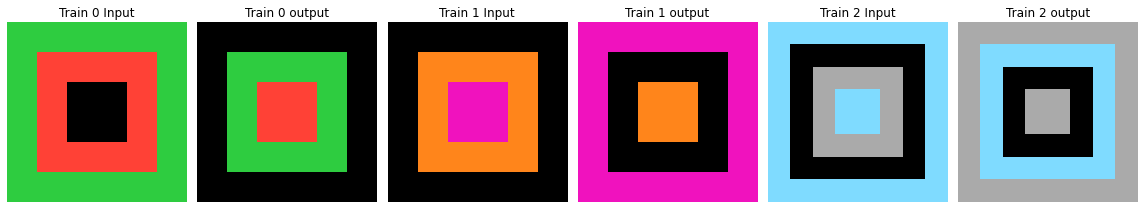

obj_staus:  irr
running_objective:  [[[('nonbg-1pr', 'nonbg0', 'direct')], [('nonbg0', 'nonbg1', 'direct')], [('nonbg1', 'nonbg-1pr', 'direct')]], [[('nonbg-1pr', 'nonbg0', 'direct')], [('nonbg0', 'nonbg1', 'direct')], [('nonbg1', 'nonbg-1pr', 'direct')]], [[('nonbg-1pr', 'nonbg1', 'direct')], [('nonbg0', 'nonbg-1pr', 'direct')], [('nonbg1', 'nonbg0', 'direct')]]]
test_objective:  [[[('nonbg-1pr', 'nonbg0', 'direct')]], [[('nonbg-1pr', 'nonbg0', 'direct')]]]
test_running_objective:  [[('nonbg-1pr', 'nonbg0', 'direct')], [('nonbg0', 'nonbg1', 'direct')], [('nonbg1', 'nonbg-1pr', 'direct')]]
365


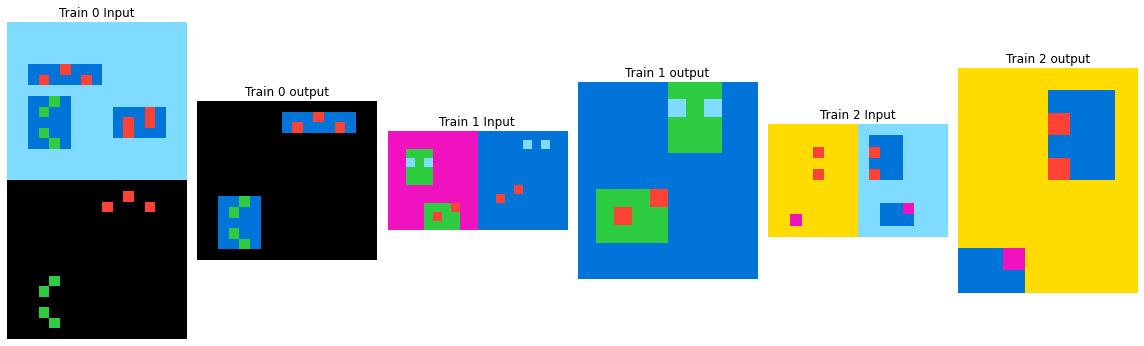

obj_staus:  irr
running_objective:  [[[('nonbg1pr', 'nil', 'direct')], [('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg3', 'nil', 'direct')], [('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nonbg1pr', 'nil', 'direct')], [('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_objective:  [[[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]]
test_running_objective:  [[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]
398


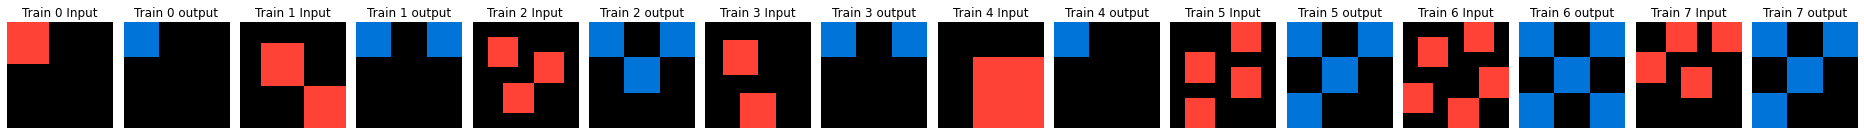

obj_staus:  irr
running_objective:  [[[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('bg', 'nonbg0pr', 'direct')], [('nonbg1pr', 'bg', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]]]
test_objective:  [[[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('bg', 'nonbg0pr', 'direct')], [('nonbg1pr', 'bg', 'direct')]]


In [19]:
for n in current_attention:
    this_task = previous_analysis[n]
    if len(this_task.test_running_objective) != len(this_task.test_objective[0]):
        print(n)
        plot_task(tt[n])
        print('obj_staus: ', this_task.objective_status)
        print('running_objective: ', this_task.running_objective)
        print('test_objective: ', this_task.test_objective)
        print('test_running_objective: ', sorted(this_task.test_running_objective))
        print('=========')

1


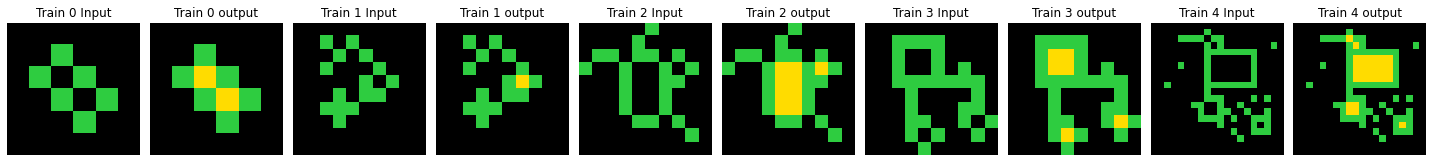

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {9, 5, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {5, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {9, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {15}, {0})]]]
test_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {9, 5, 15}, {0})]]
20


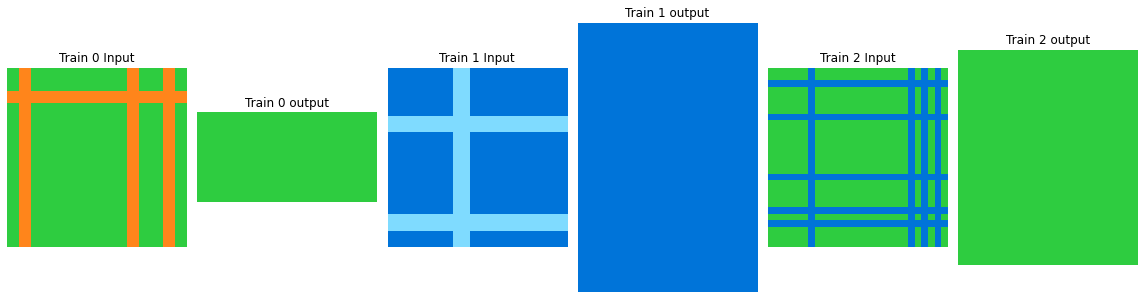

obj_staus:  obd
running_objective:  [[[('nonbg-1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 7], (1, {1, 3}), (4, {168, 506, 90}), (5, {1}), (7, {1})]], [[('nonbg-1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 6, 7], (1, {1}), (4, {90}), (5, {1}), (6, {1, 3}), (7, {1})]], [[('nonbg-1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 7], (1, {3}), (4, {506}), (5, {1}), (7, {1})]]]
test_objective:  [[[('nonbg-1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct')]]]
test_running_objective:  [[('nonbg-1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 7], (1, {1, 3}), (4, {168, 506, 90}), (5, {1}), (7, {1})]]
35


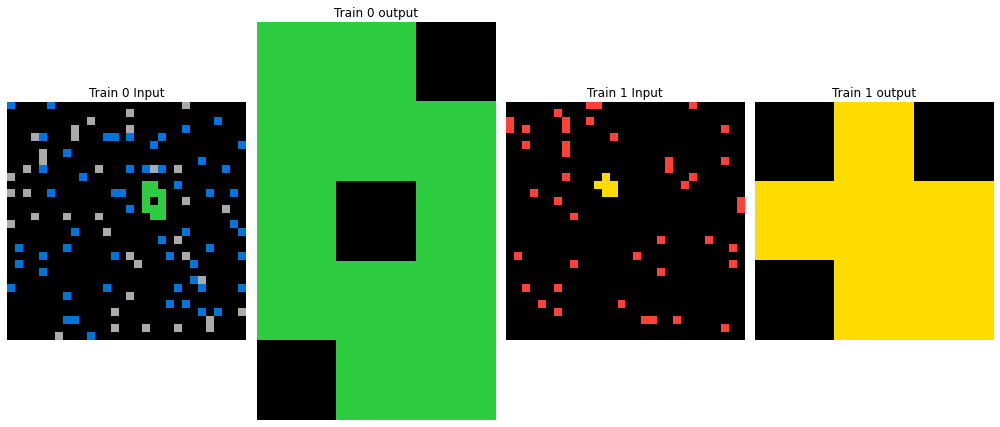

obj_staus:  red
running_objective:  [[[('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0', 'nonbg0', 'direct')]], [[('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0', 'nonbg0', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')]]
45


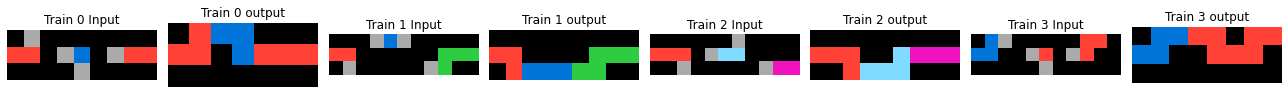

obj_staus:  red
running_objective:  [[[('nonbg1pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nonbg1pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg1pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg1pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3',

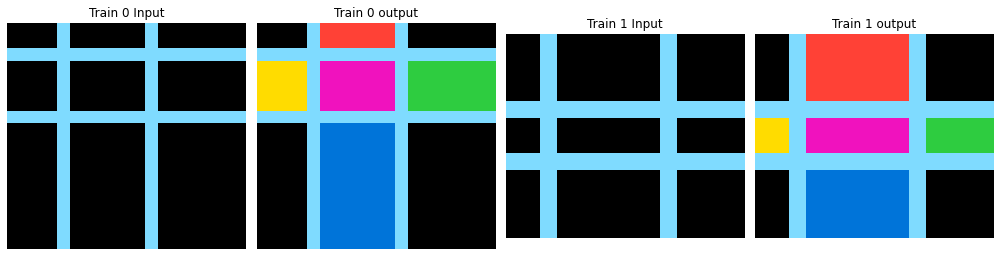

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {8, 9, 5, 7}, {4})], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {8, 9, 5, 7}, {2})], [('bg', 'bg'), ('bg', 'nonbg2pr'), [6], (6, {8, 9, 5, 7}, {1})], [('bg', 'bg'), ('bg', 'nonbg3pr'), [6], (6, {8, 9, 5, 7}, {3})], [('bg', 'bg'), ('bg', 'nonbg4pr'), [6], (6, {8, 9, 5, 7}, {0})], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [2, 6], (2, {8, 9, 10, 11, 12, 13, 14, 15, 16, 17}, {0, 1, 2, 3}), (6, {4}, {2})], [('bg', 'nonbg0pr'), ('bg', 'nonbg2pr'), [2, 6], (2, {8, 9, 10, 11, 12, 13, 14, 15, 16, 17}, {3, 4, 5, 6}), (6, {4}, {1})], [('bg', 'nonbg0pr'), ('bg', 'nonbg3pr'), [2, 6], (2, {8, 9, 10, 11, 12, 13, 14, 15, 16, 17}, {3, 4, 5, 6}), (6, {4}, {3})], [('bg', 'nonbg0pr'), ('bg', 'nonbg4pr'), [2, 6], (2, {8, 9, 10, 11, 12, 13, 14, 15, 16, 17}, {3, 4, 5, 6}), (6, {4}, {0})], [('bg', 'nonbg1pr'), ('bg', 'nonbg2pr'), [6], (6, {2}, {1})], [('bg', 'nonbg1pr'), ('bg', 'nonbg3pr'), [6], (6, {2}, {3})], [('bg', 'nonbg1pr

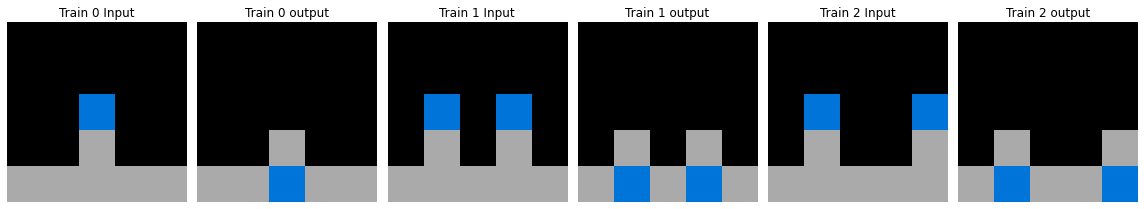

obj_staus:  obd
running_objective:  [[[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {11, 15}, {9, 4})]], [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {11, 15}, {4})]], [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {11, 15}, {9, 4})]]]
test_objective:  [[[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr')]]]
test_running_objective:  [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {11, 15}, {9, 4})]]
94


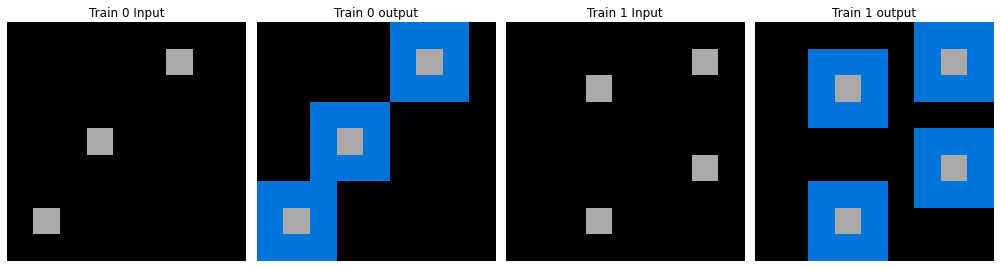

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]]]
test_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]]
96


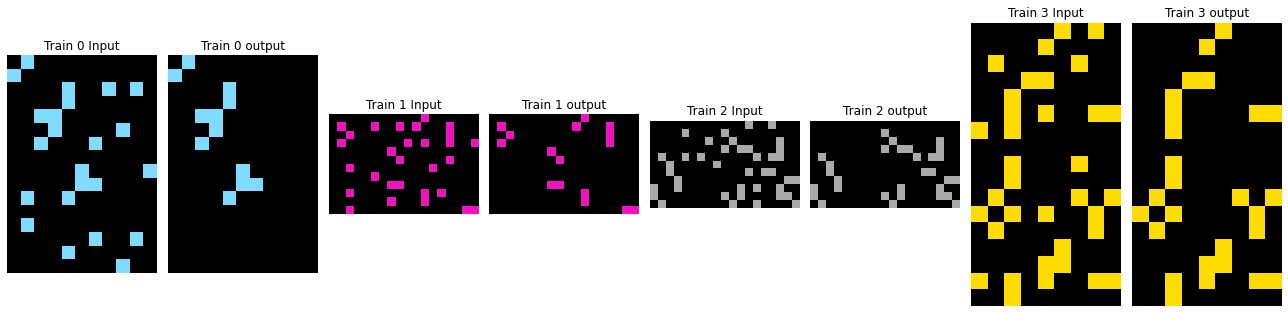

obj_staus:  obd
running_objective:  [[[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [7], (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [7], (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [7], (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [7], (7, {2}, {1})]]]
test_objective:  [[[('nonbg0', 'nonbg0'), ('nonbg0', 'bg')]]]
test_running_objective:  [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [7], (7, {2}, {1})]]
106


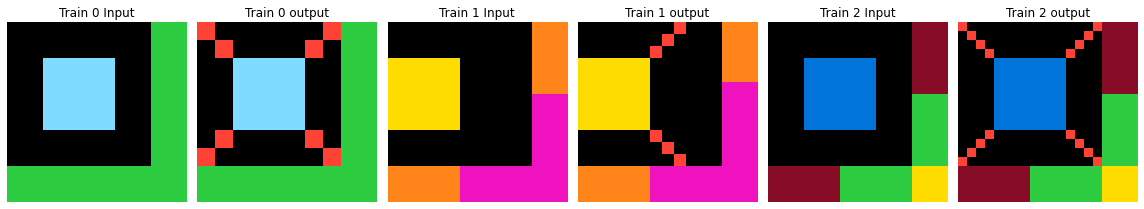

obj_staus:  red
running_objective:  [[[('nil', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nil', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nil', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nil', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nil', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]
119


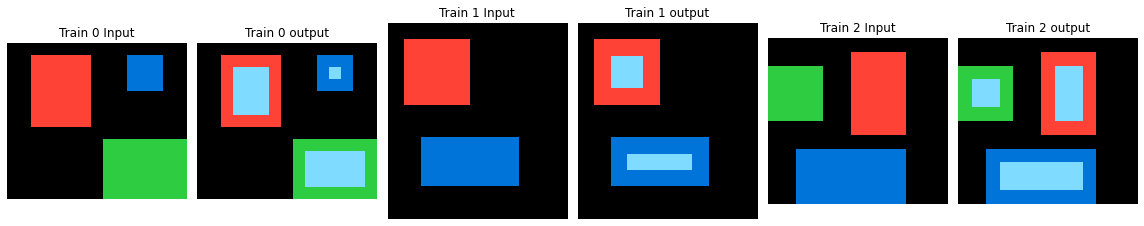

obj_staus:  red
running_objective:  [[[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr'), [6], (6, {4, 15}, {0})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg3', 'nonbg3'), ('nonbg3', 'nonbg2pr'), [6], (6, {1, 3, 4, 9, 15}, {0})]], [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]], [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr'), [6], (6, {4, 15}, {0})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg3', 'nonbg3'), ('nonbg3', 'nonbg2pr'), [6], (6, {3, 15}, {0})]]]
test_objective:  [[[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr')], [('nonbg3', 'nonbg3'), ('nonbg3', 'nonbg2pr')]]]
test_running_objective:  [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr'), [6], (6, {4, 15}, {0}

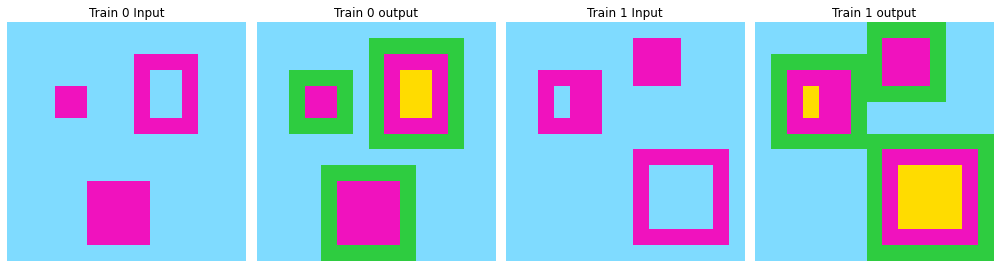

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]]]
test_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1pr')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]]
182


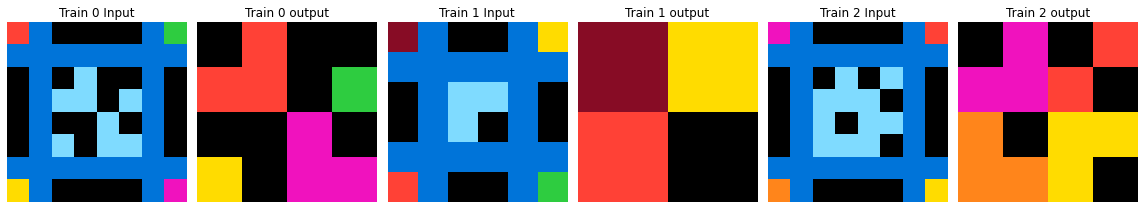

obj_staus:  irr
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg4', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg5', 'nonbg5', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonb

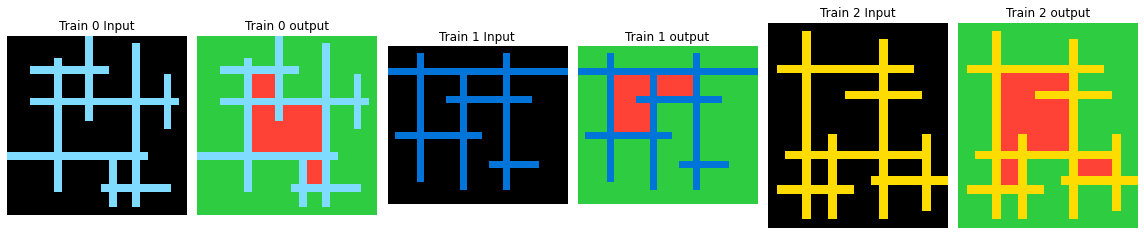

obj_staus:  obd
running_objective:  [[[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {0}, {13, 11, 5, 15})]], [[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {0}, {11, 13})]], [[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {0}, {15})]]]
test_objective:  [[[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr')]]]
test_running_objective:  [[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {0}, {13, 11, 5, 15})]]
212


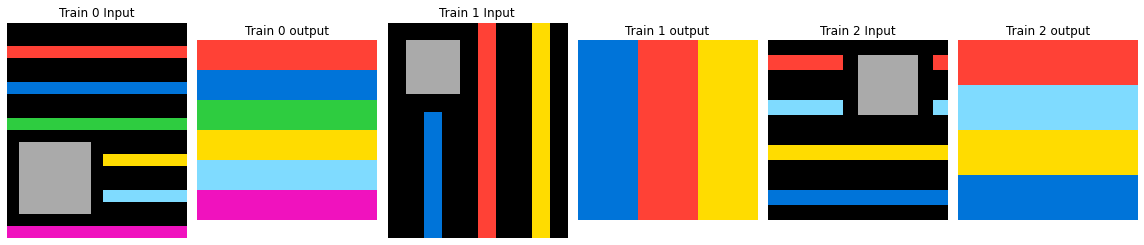

obj_staus:  red
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')], [('nonbg6', 'nonbg6', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')], [('nonbg6', 'nonbg6', 'direct')]]]
tes

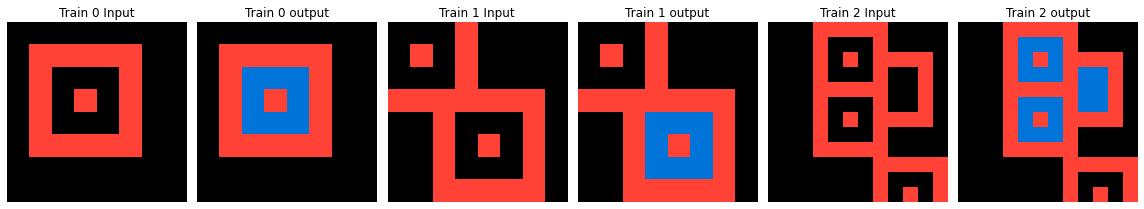

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {4, 5, 7, 8, 12, 14, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {8, 5, 14}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {12, 4, 7}, {0})]]]
test_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {4, 5, 7, 8, 12, 14, 15}, {0})]]
251


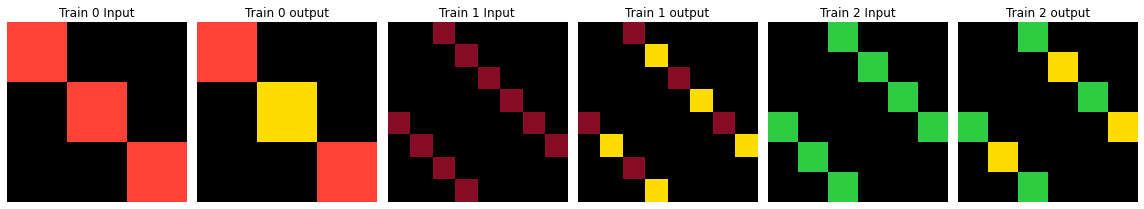

obj_staus:  obd
running_objective:  [[[('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr'), [3], (3, {0, 2, 4, 6}, {1, 3, 5, 7})]], [[('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr'), [2, 3], (2, {0, 2, 4, 6}, {1, 3, 5, 7}), (3, {0, 2, 4, 6}, {1, 3, 5, 7})]], [[('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr'), [3], (3, {0, 2, 4}, {1, 3, 5})]]]
test_objective:  [[[('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr')]]]
test_running_objective:  [[('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr'), [3], (3, {0, 2, 4, 6}, {1, 3, 5, 7})]]
258


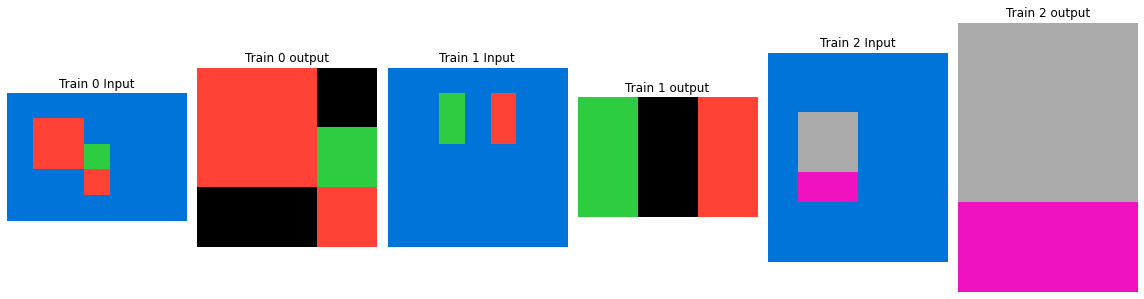

obj_staus:  irr
running_objective:  [[[('bg', 'nonbg2', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]], [[('bg', 'nonbg2', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]]
test_running_objective:  [[('bg', 'nonbg2', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]
274


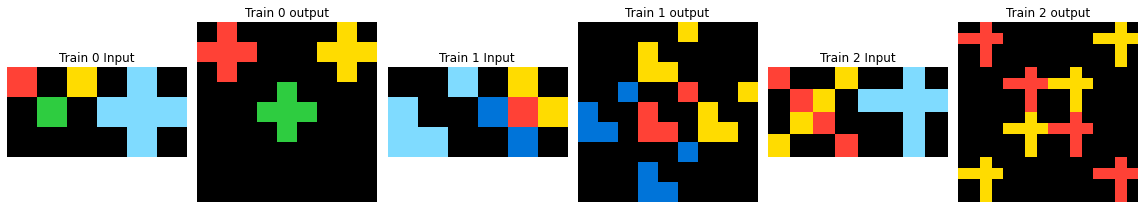

obj_staus:  red
running_objective:  [[[('nonbg2pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg2pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg2pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nil', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nil', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]
291


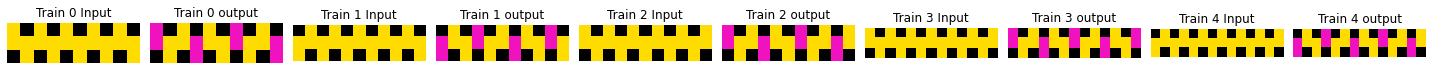

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10, 11, 13}, {0, 3, 6, 9, 12})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10}, {0, 9, 3, 6})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10}, {0, 9, 3, 6})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10, 11}, {0, 3, 6, 9, 12})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10, 11, 13}, {0, 3, 6, 9, 12})]]]
test_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10, 11, 13}, {0, 3, 6, 9, 12})]]
292


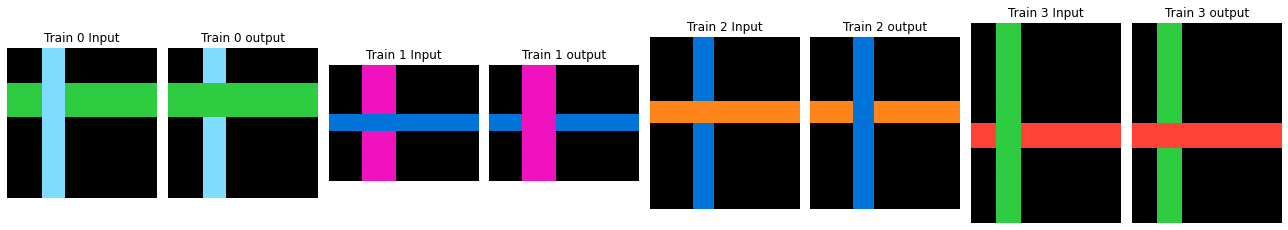

obj_staus:  irr
running_objective:  [[[('nonbg1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [6], (6, {5, 7, 8, 9, 12, 14}, {0})]], [[('nonbg1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [3, 6], (3, {0, 1, 4, 5, 6, 7, 8}, {2, 3}), (6, {12, 14}, {0})]], [[('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0'), [3, 6], (3, {0, 1, 3, 4, 5, 6}, {2}), (6, {12, 14}, {0})]], [[('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0'), [2, 6], (2, {0, 1, 2, 3, 5, 6, 7}, {4}), (6, {11, 13}, {0})]]]
test_objective:  [[[('nonbg1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1')]]]
test_running_objective:  [[('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [6], (6, {5, 7, 8, 9, 12, 14}, {0})], [('nonbg1', 'nonbg1', 'direct')]]
293


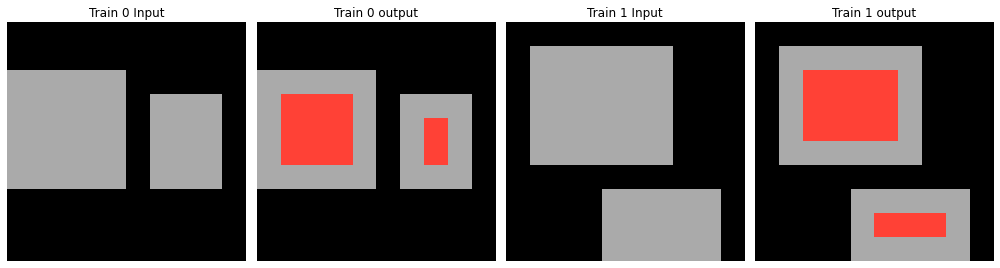

obj_staus:  obd
running_objective:  [[[('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {3, 4, 15}, {0})]], [[('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {4, 15}, {0})]]]
test_objective:  [[[('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr')]]]
test_running_objective:  [[('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {3, 4, 15}, {0})]]
299


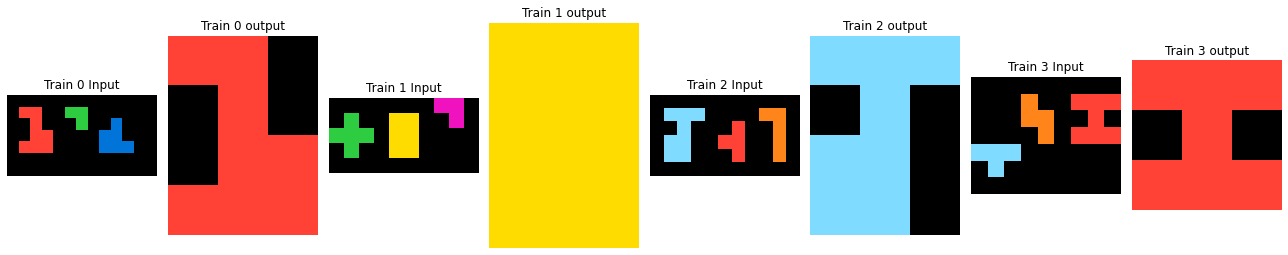

obj_staus:  irr
running_objective:  [[[('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]
316


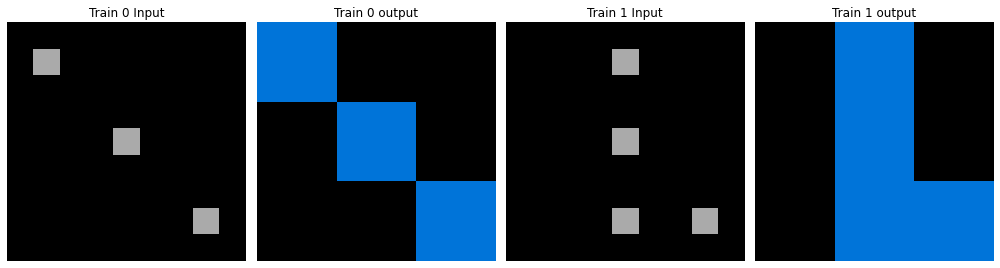

obj_staus:  obd
running_objective:  [[[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]]]
test_objective:  [[[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})], [('nonbg1pr', 'nonbg0pr', 'direct')]]
328


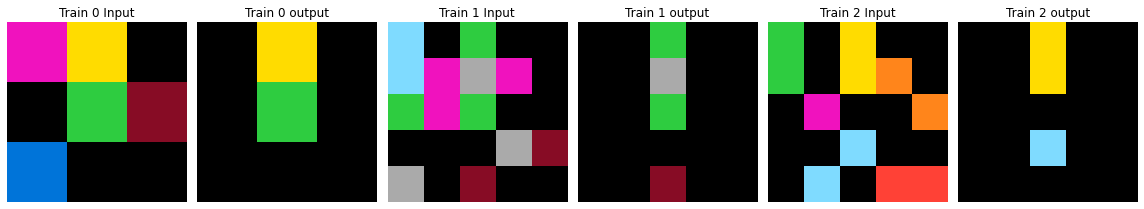

obj_staus:  irr
running_objective:  [[[('nonbg0pr', 'bg', 'direct')], [('nonbg1', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')]], [[('nonbg1pr', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'bg'), [3, 6], (3, {2}, {0}), (6, {7, 15}, {8})], [('nonbg3', 'nonbg3'), ('nonbg3', 'bg'), [2, 3, 6], (2, {4}, {3}), (3, {2}, {4}), (6, {13}, {14})], [('nonbg4', 'nonbg4'), ('nonbg4', 'bg'), [3, 6], (3, {2}, {0, 1, 3}), (6, {0, 13}, {8, 15})]], [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')], [('nonbg3', 'bg', 'direct')], [('nonbg4', 'nonbg4'), ('nonbg4', 'bg'), [2, 3, 6, 7], (2, {3}, {4}), (3, {2}, {1}), (6, {13}, {8}), (7, {4}, {2})]]]
test_objective:  [[[('nonbg1pr', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'bg')], [('nonbg3', 'nonbg3'), ('nonbg3', 'bg')], [('nonbg4', 'nonbg4'), ('nonbg4', 'bg')]]]
test_running_objective:  [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr'

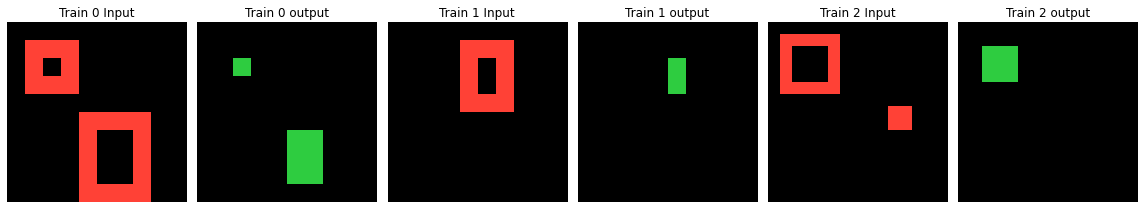

obj_staus:  obd
running_objective:  [[[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]], [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]], [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]]]
test_objective:  [[[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr')]], [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})], [('nonbg0pr', 'bg', 'direct')]]
345


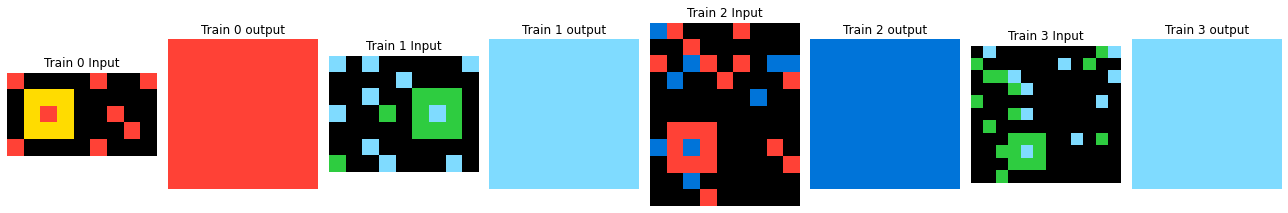

obj_staus:  irr
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct'), [1, 6], (1, {8}), (6, {0})]], [[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 6], (1, {1}), (4, {9}), (5, {0}), (6, {5})]], [[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {8}), (4, {10}), (5, {0})]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct')]]]
test_running_objective:  [[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]
372


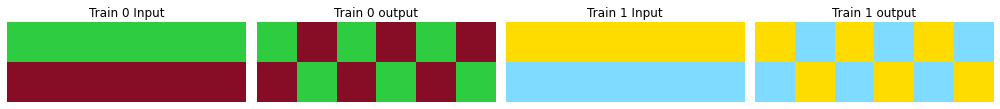

obj_staus:  obd
running_objective:  [[[('nonbg-1', 'nonbg-1'), ('nonbg-1', 'nonbg0'), [3], (3, {0, 2, 4}, {1, 3, 5})], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1'), [3], (3, {0, 2, 4}, {1, 3, 5})]], [[('nonbg-1', 'nonbg-1'), ('nonbg-1', 'nonbg0'), [3], (3, {0, 2, 4}, {1, 3, 5})], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1'), [3], (3, {0, 2, 4}, {1, 3, 5})]]]
test_objective:  [[[('nonbg-1', 'nonbg-1'), ('nonbg-1', 'nonbg0')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1')]]]
test_running_objective:  [[('nonbg-1', 'nonbg-1'), ('nonbg-1', 'nonbg0'), [3], (3, {0, 2, 4}, {1, 3, 5})], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1'), [3], (3, {0, 2, 4}, {1, 3, 5})]]


In [18]:
for n in current_attention:
    this_task = previous_analysis[n]
    if len(this_task.test_running_objective) == len(this_task.test_objective[0]):
        print(n)
        plot_task(tt[n])
        print('obj_staus: ', this_task.objective_status)
        print('running_objective: ', this_task.running_objective)
        print('test_objective: ', this_task.test_objective)
        print('test_running_objective: ', sorted(this_task.test_running_objective))
        print('=========')

1


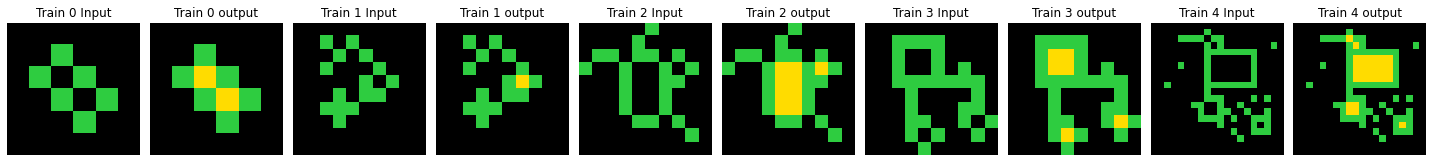

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {9, 5, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {5, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {9, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {15}, {0})]]]
test_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {9, 5, 15}, {0})]]
20


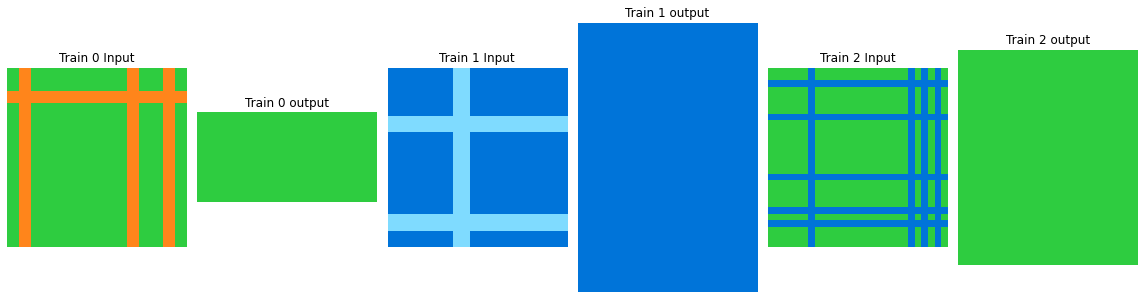

obj_staus:  obd
running_objective:  [[[('nonbg-1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 7], (1, {1, 3}), (4, {168, 506, 90}), (5, {1}), (7, {1})]], [[('nonbg-1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 6, 7], (1, {1}), (4, {90}), (5, {1}), (6, {1, 3}), (7, {1})]], [[('nonbg-1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 7], (1, {3}), (4, {506}), (5, {1}), (7, {1})]]]
test_objective:  [[[('nonbg-1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct')]]]
test_running_objective:  [[('nonbg-1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 7], (1, {1, 3}), (4, {168, 506, 90}), (5, {1}), (7, {1})]]
28


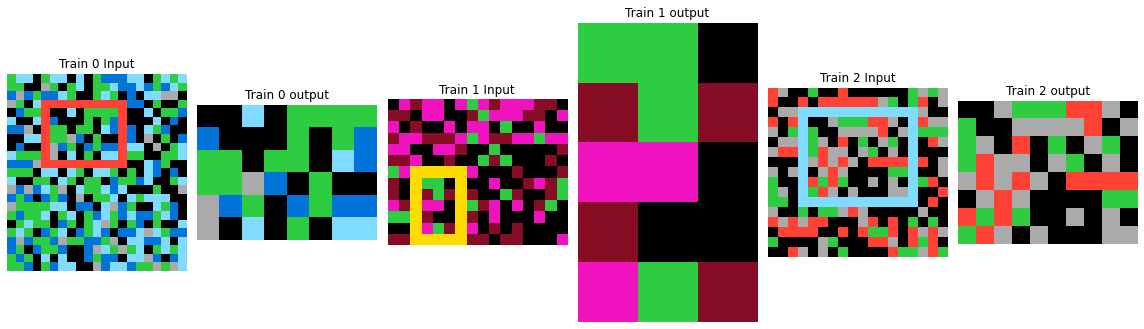

obj_staus:  irr
running_objective:  [[[('nonbg2', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]], [[('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_objective:  [[[('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_running_objective:  [[('nonbg2', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]
35


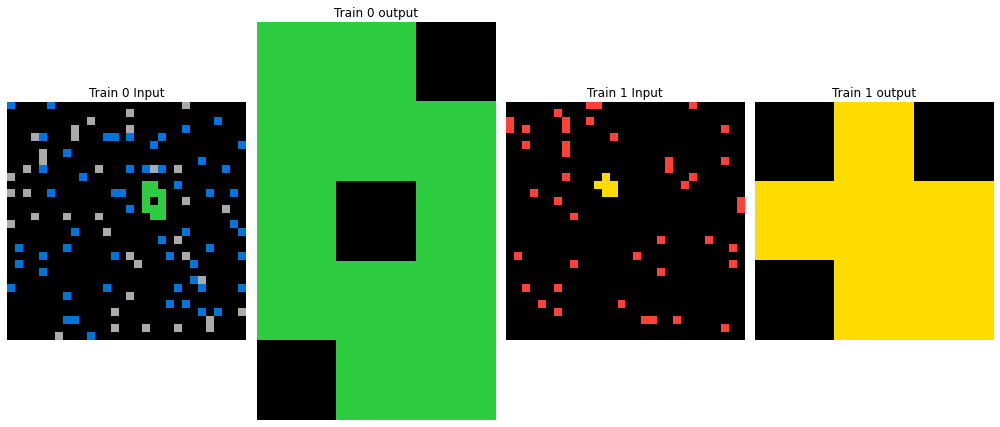

obj_staus:  red
running_objective:  [[[('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0', 'nonbg0', 'direct')]], [[('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0', 'nonbg0', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')]]]
test_running_objective:  [[('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0', 'nonbg0', 'direct')]]
38


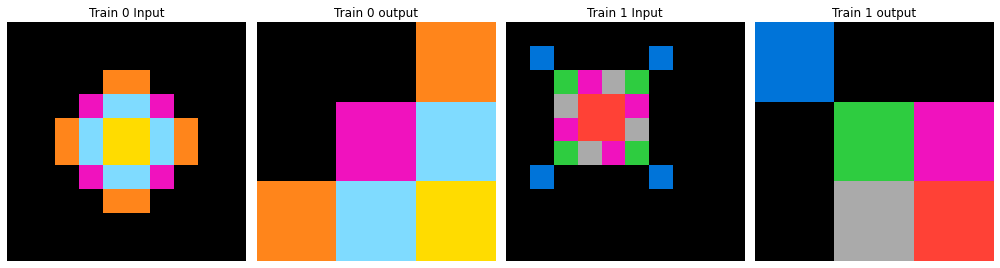

obj_staus:  red
running_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_running_objective:  [[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]
45


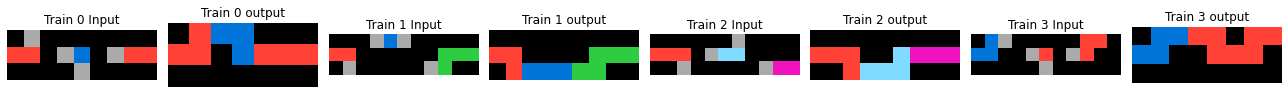

obj_staus:  red
running_objective:  [[[('nonbg1pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nonbg1pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg1pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg1pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_running_objective:  [[('nonbg1pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3',

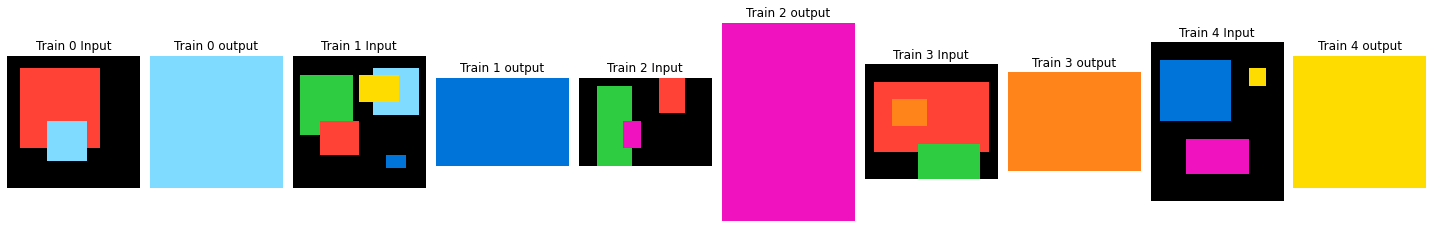

obj_staus:  red
running_objective:  [[[('nonbg-1pr', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {8}), (4, {9}), (5, {0})]], [[('nonbg-1pr', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nil', 'direct')], [('nonbg4', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {1, 4, 6, 7, 8}), (4, {9, 4, 12, 6}), (5, {0})]], [[('nonbg-1pr', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {6}), (4, {6}), (5, {0})]], [[('nonbg-1pr', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {7}), (4, {12}), (5, {0})]], [[('nonbg-1pr', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {4}), (4, {4}), (5, {0})]]]
test_objective:  [[[('nonbg-1pr', 'nil', 'di

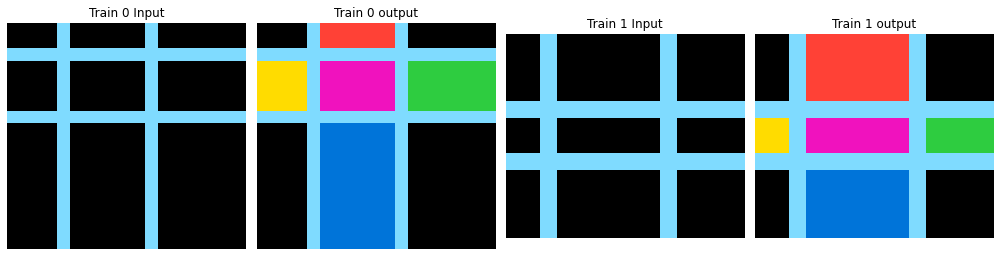

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {8, 9, 5, 7}, {4})], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {8, 9, 5, 7}, {2})], [('bg', 'bg'), ('bg', 'nonbg2pr'), [6], (6, {8, 9, 5, 7}, {1})], [('bg', 'bg'), ('bg', 'nonbg3pr'), [6], (6, {8, 9, 5, 7}, {3})], [('bg', 'bg'), ('bg', 'nonbg4pr'), [6], (6, {8, 9, 5, 7}, {0})], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [2, 6], (2, {8, 9, 10, 11, 12, 13, 14, 15, 16, 17}, {0, 1, 2, 3}), (6, {4}, {2})], [('bg', 'nonbg0pr'), ('bg', 'nonbg2pr'), [2, 6], (2, {8, 9, 10, 11, 12, 13, 14, 15, 16, 17}, {3, 4, 5, 6}), (6, {4}, {1})], [('bg', 'nonbg0pr'), ('bg', 'nonbg3pr'), [2, 6], (2, {8, 9, 10, 11, 12, 13, 14, 15, 16, 17}, {3, 4, 5, 6}), (6, {4}, {3})], [('bg', 'nonbg0pr'), ('bg', 'nonbg4pr'), [2, 6], (2, {8, 9, 10, 11, 12, 13, 14, 15, 16, 17}, {3, 4, 5, 6}), (6, {4}, {0})], [('bg', 'nonbg1pr'), ('bg', 'nonbg2pr'), [6], (6, {2}, {1})], [('bg', 'nonbg1pr'), ('bg', 'nonbg3pr'), [6], (6, {2}, {3})], [('bg', 'nonbg1pr

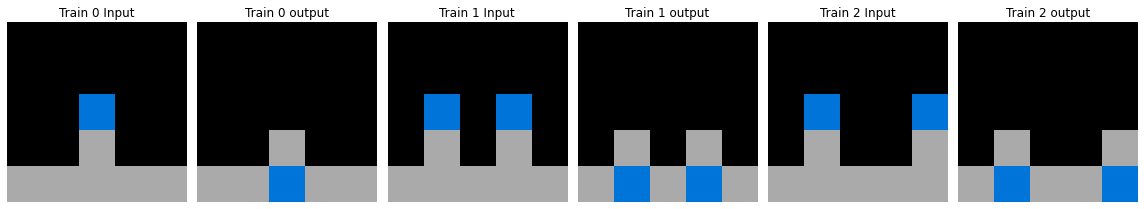

obj_staus:  obd
running_objective:  [[[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {11, 15}, {9, 4})]], [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {11, 15}, {4})]], [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {11, 15}, {9, 4})]]]
test_objective:  [[[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr')]]]
test_running_objective:  [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {11, 15}, {9, 4})]]
94


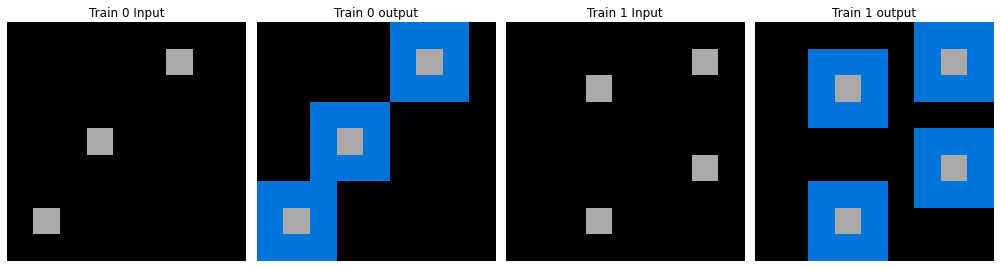

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]]]
test_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]]
95


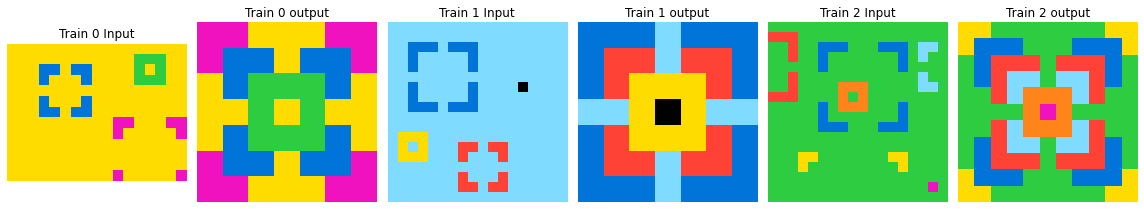

obj_staus:  red
running_objective:  [[[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]]]
test_objective:  [[[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_running_objective:  [[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2',

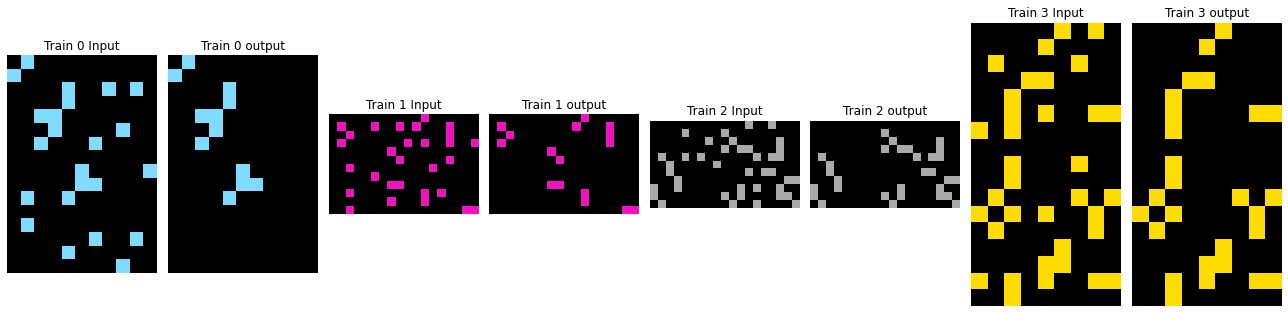

obj_staus:  obd
running_objective:  [[[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [7], (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [7], (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [7], (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [7], (7, {2}, {1})]]]
test_objective:  [[[('nonbg0', 'nonbg0'), ('nonbg0', 'bg')]]]
test_running_objective:  [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [7], (7, {2}, {1})]]
97


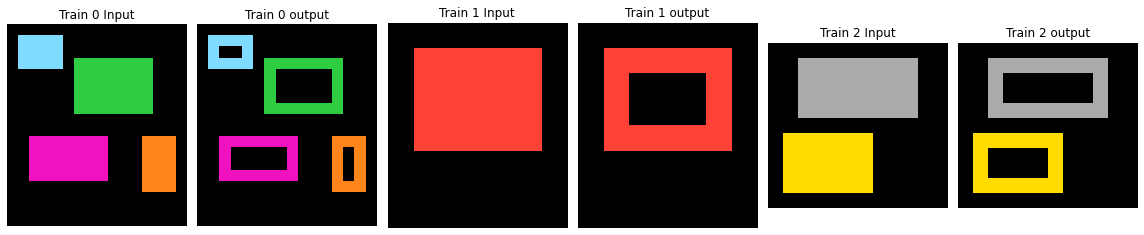

obj_staus:  red
running_objective:  [[[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg2', 'nonbg2'), ('nonbg2', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg3', 'nonbg3'), ('nonbg3', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]], [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]]]
test_objective:  [[[('nonbg0', 'nonbg0'), ('nonbg0', 'bg')], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg')], [('nonbg2', 'nonbg2'), ('nonbg2', 'bg')], [('nonbg3', 'nonbg3'), ('nonbg3', 'bg')], [('nonbg4', 'nonbg4'), ('nonbg4', 'bg')]]]
test_running_objective:  [[('nonbg0', 'nonbg0'), ('nonbg0', 'bg'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1', 'nonbg1'), ('nonbg1', 'bg'), [6, 7], (6, 

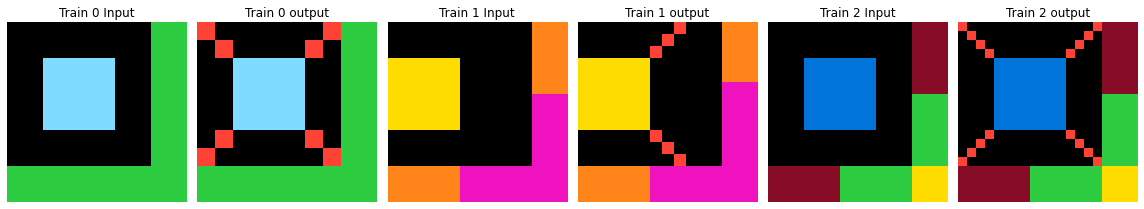

obj_staus:  red
running_objective:  [[[('nil', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nil', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nil', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nil', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_running_objective:  [[('nil', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]
119


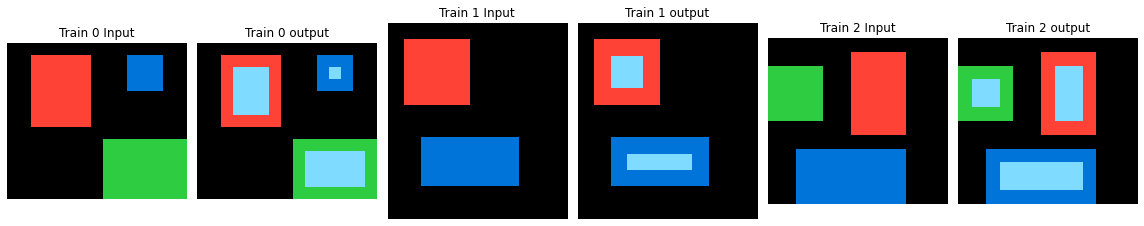

obj_staus:  red
running_objective:  [[[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr'), [6], (6, {4, 15}, {0})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg3', 'nonbg3'), ('nonbg3', 'nonbg2pr'), [6], (6, {1, 3, 4, 9, 15}, {0})]], [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})]], [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr'), [6], (6, {4, 15}, {0})], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr'), [6, 7], (6, {15}, {0}), (7, {2}, {1})], [('nonbg3', 'nonbg3'), ('nonbg3', 'nonbg2pr'), [6], (6, {3, 15}, {0})]]]
test_objective:  [[[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr')], [('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg2pr')], [('nonbg3', 'nonbg3'), ('nonbg3', 'nonbg2pr')]]]
test_running_objective:  [[('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'nonbg2pr'), [6], (6, {4, 15}, {0}

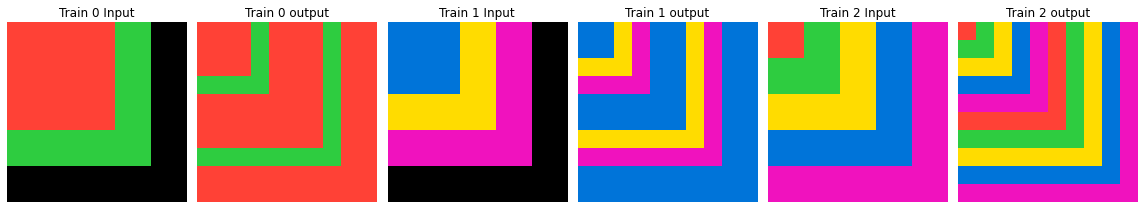

obj_staus:  irr
running_objective:  [[[('nonbg0', 'nil', 'direct')], [('nonbg-1', 'nonbg-1', 'direct')], [('nonbg1', 'nonbg1', 'direct')]], [[('nonbg2', 'nil', 'direct')], [('nonbg-1', 'nonbg-1', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]], [[('nonbg-1', 'nonbg-1', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_objective:  [[[('nonbg0', 'nil', 'direct')], [('nonbg-1', 'nonbg-1', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]]
test_running_objective:  [[('nonbg-1', 'nonbg-1', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]
124


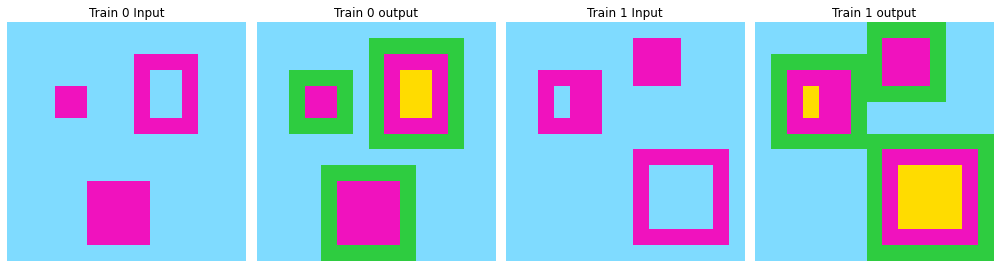

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]]]
test_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr')], [('bg', 'bg'), ('bg', 'nonbg1pr')], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})], [('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]]
129


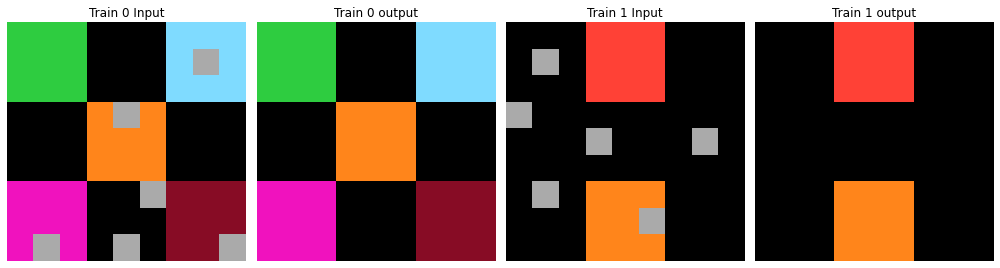

obj_staus:  red
running_objective:  [[[('nonbg0pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]], [[('nonbg0pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0pr', 'nil', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_running_objective:  [[('nonbg0pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]]
182


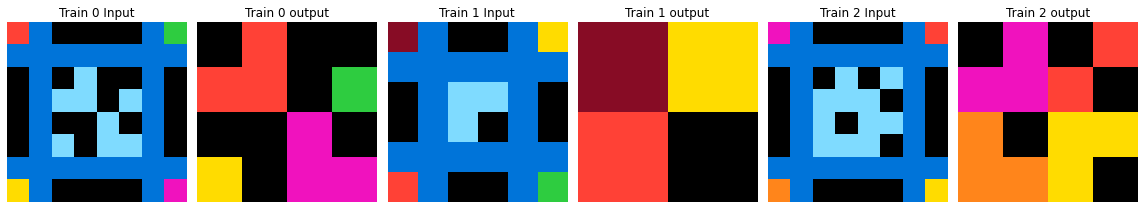

obj_staus:  irr
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg4', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg5', 'nonbg5', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonb

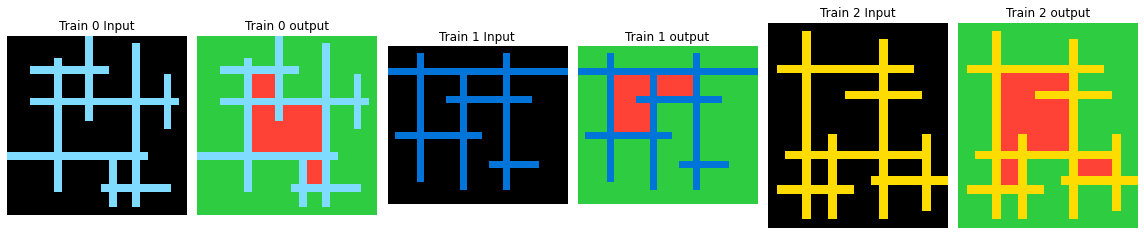

obj_staus:  obd
running_objective:  [[[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {0}, {13, 11, 5, 15})]], [[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {0}, {11, 13})]], [[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {0}, {15})]]]
test_objective:  [[[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr')]]]
test_running_objective:  [[('bg', 'nonbg0pr'), ('bg', 'nonbg1pr'), [6], (6, {0}, {13, 11, 5, 15})]]
212


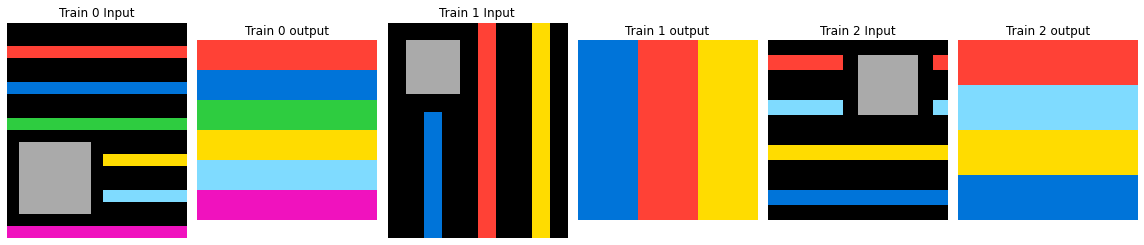

obj_staus:  red
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')], [('nonbg6', 'nonbg6', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nil', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')], [('nonbg6', 'nonbg6', 'direct')]]]
tes

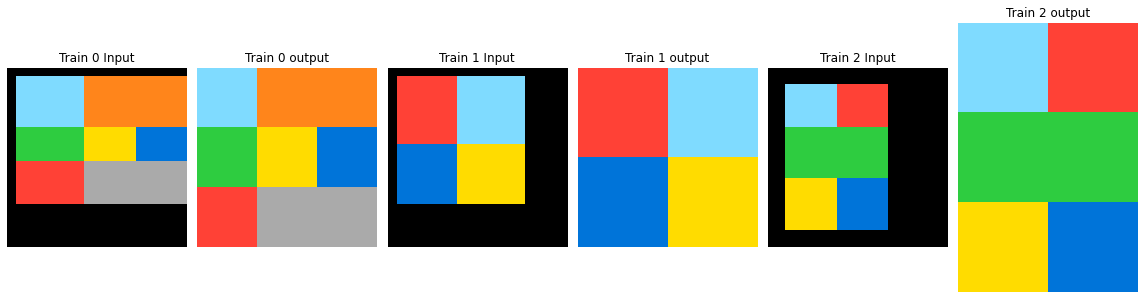

obj_staus:  red
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nonbg3pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')], [('nonbg6', 'nonbg6', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nonbg3pr', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nonbg3pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nonbg2pr', 'direct')], [('nonbg3pr', 'nonbg3pr', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_running_objective:  [[('bg', 'nil', 'direct')]

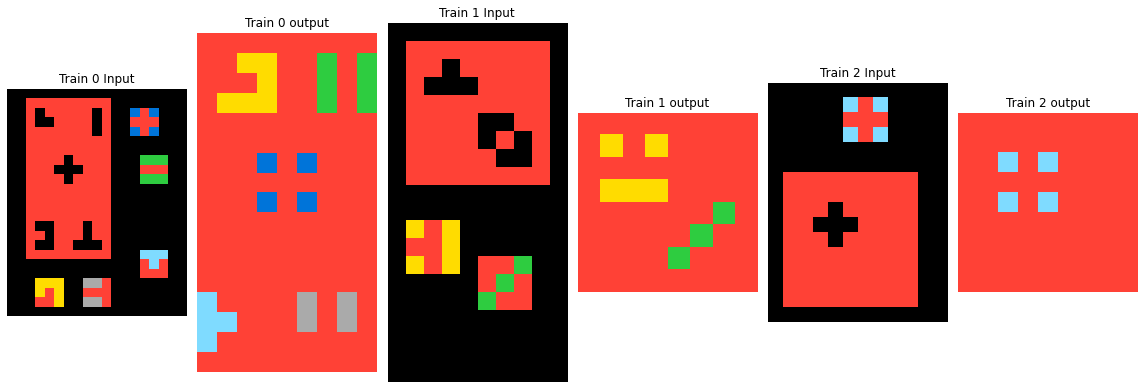

obj_staus:  red
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')]]]
test_running_objective:  [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1', 'nonbg1', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')], [('nonbg4', 'nonbg4', 'direct')], [('nonbg5', 'nonbg5', 'direct')]]
234


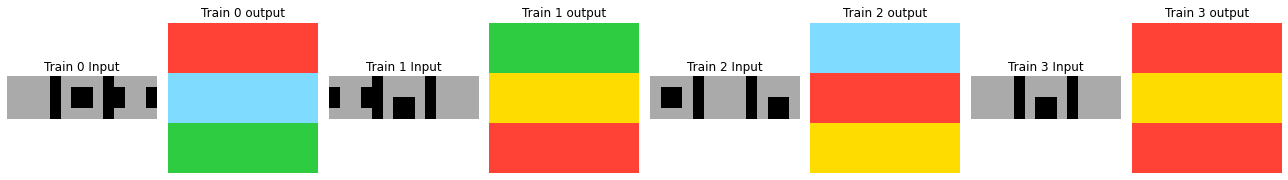

obj_staus:  red
running_objective:  [[[('bg', 'nonbg1pr', 'direct')], [('bg', 'nonbg2', 'direct')], [('bg', 'nonbg3', 'direct')], [('nonbg0pr', 'nonbg1pr', 'direct')], [('nonbg0pr', 'nonbg2', 'direct')], [('nonbg0pr', 'nonbg3', 'direct')]], [[('bg', 'nonbg1pr', 'direct')], [('bg', 'nonbg2', 'direct')], [('bg', 'nonbg3', 'direct')], [('nonbg0pr', 'nonbg1pr', 'direct')], [('nonbg0pr', 'nonbg2', 'direct')], [('nonbg0pr', 'nonbg3', 'direct')]], [[('bg', 'nonbg1pr', 'direct')], [('bg', 'nonbg2', 'direct')], [('bg', 'nonbg3', 'direct')], [('nonbg0pr', 'nonbg1pr', 'direct')], [('nonbg0pr', 'nonbg2', 'direct')], [('nonbg0pr', 'nonbg3', 'direct')]], [[('bg', 'nonbg1pr', 'direct')], [('bg', 'nonbg2', 'direct')], [('nonbg0pr', 'nonbg1pr', 'direct')], [('nonbg0pr', 'nonbg2', 'direct')]]]
test_objective:  [[]]
test_running_objective:  [[('bg', 'nonbg1pr', 'direct')], [('bg', 'nonbg2', 'direct')], [('bg', 'nonbg3', 'direct')], [('nonbg0pr', 'nonbg1pr', 'direct')], [('nonbg0pr', 'nonbg2', 'direct')],

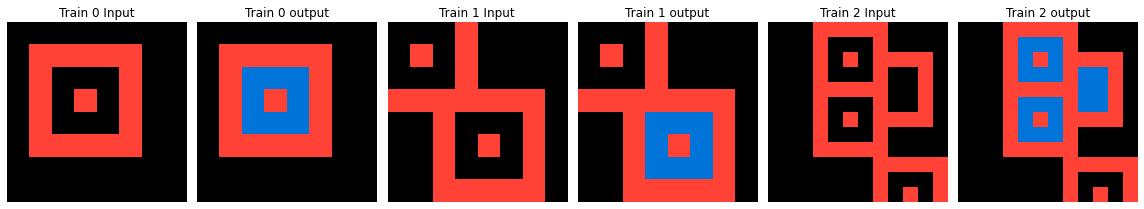

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {4, 5, 7, 8, 12, 14, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {8, 5, 14}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {12, 4, 7}, {0})]]]
test_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {4, 5, 7, 8, 12, 14, 15}, {0})]]
251


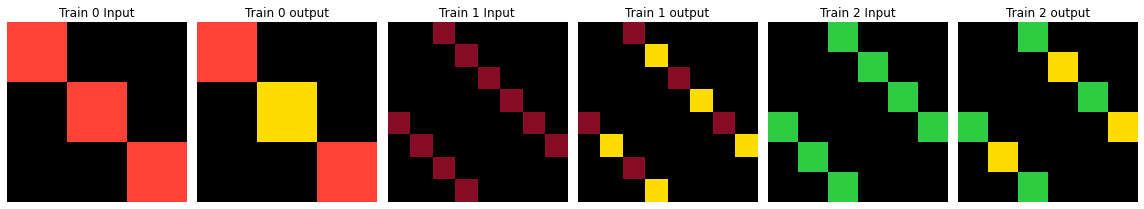

obj_staus:  obd
running_objective:  [[[('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr'), [3], (3, {0, 2, 4, 6}, {1, 3, 5, 7})]], [[('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr'), [2, 3], (2, {0, 2, 4, 6}, {1, 3, 5, 7}), (3, {0, 2, 4, 6}, {1, 3, 5, 7})]], [[('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr'), [3], (3, {0, 2, 4}, {1, 3, 5})]]]
test_objective:  [[[('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr')]]]
test_running_objective:  [[('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0pr'), [3], (3, {0, 2, 4, 6}, {1, 3, 5, 7})]]
258


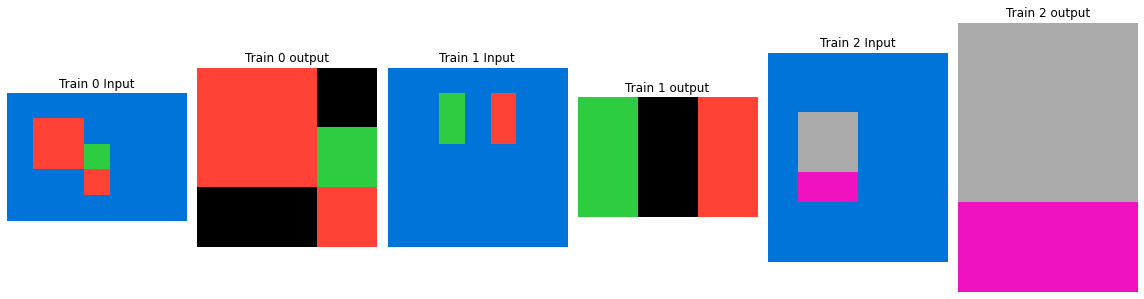

obj_staus:  irr
running_objective:  [[[('bg', 'nonbg2', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]], [[('bg', 'nonbg2', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]]
test_running_objective:  [[('bg', 'nonbg2', 'direct')], [('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]
274


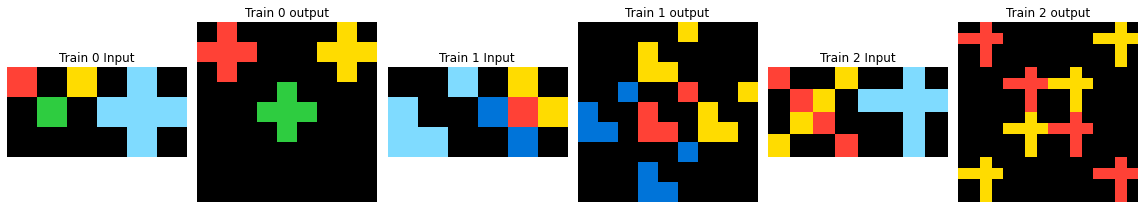

obj_staus:  red
running_objective:  [[[('nonbg2pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg2pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg2pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2pr', 'nil', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_running_objective:  [[('nonbg2pr', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]
290


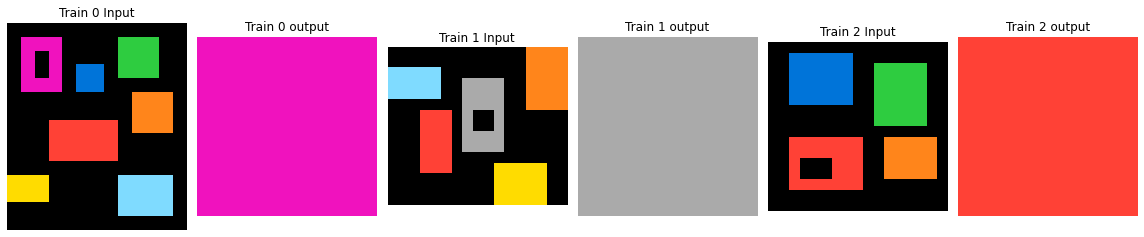

obj_staus:  irr
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nil', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nil', 'direct')], [('nonbg4', 'nil', 'direct')], [('nonbg6', 'nil', 'direct')], [('nonbg5', 'nonbg5', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0pr', 'nil', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nil', 'direct')], [('nonbg4', 'nonbg4', 'direct'), [1], (1, {5})]], [[('bg', 'nil', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nil', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct'), [1, 4, 5], (1, {2}), (4, {29}), (5, {1})]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg0pr', 'nil', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nil', 'direct')], [('nonbg3', 'nil', 'direct')], [('nonbg4', 'nil', 'direct')], [('nonbg5', 'nonbg5', 'direct')]]]
test_running_objective:  [[('bg', 'nil', 'direct')], [('nonb

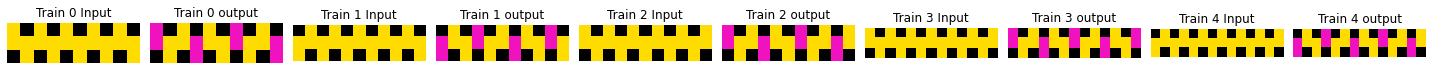

obj_staus:  obd
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10, 11, 13}, {0, 3, 6, 9, 12})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10}, {0, 9, 3, 6})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10}, {0, 9, 3, 6})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10, 11}, {0, 3, 6, 9, 12})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10, 11, 13}, {0, 3, 6, 9, 12})]]]
test_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr')]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [3], (3, {1, 2, 4, 5, 7, 8, 10, 11, 13}, {0, 3, 6, 9, 12})]]
292


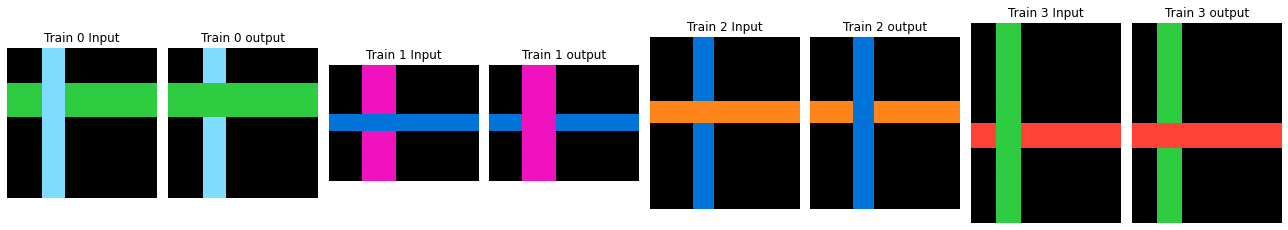

obj_staus:  irr
running_objective:  [[[('nonbg1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [6], (6, {5, 7, 8, 9, 12, 14}, {0})]], [[('nonbg1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [3, 6], (3, {0, 1, 4, 5, 6, 7, 8}, {2, 3}), (6, {12, 14}, {0})]], [[('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0'), [3, 6], (3, {0, 1, 3, 4, 5, 6}, {2}), (6, {12, 14}, {0})]], [[('nonbg0', 'nonbg0', 'direct')], [('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0'), [2, 6], (2, {0, 1, 2, 3, 5, 6, 7}, {4}), (6, {11, 13}, {0})]]]
test_objective:  [[[('nonbg1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1')]]]
test_running_objective:  [[('nonbg1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [6], (6, {5, 7, 8, 9, 12, 14}, {0})]]
293


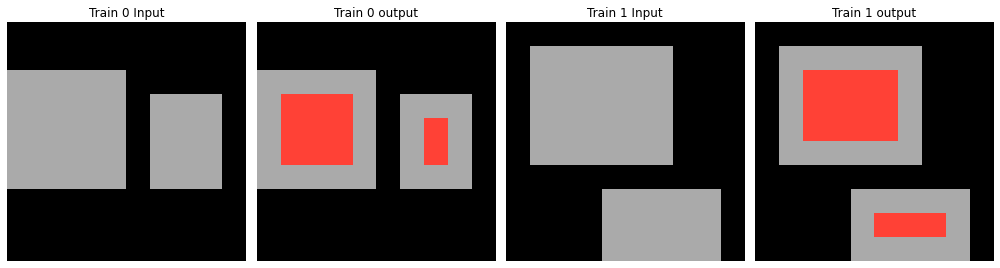

obj_staus:  obd
running_objective:  [[[('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {3, 4, 15}, {0})]], [[('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {4, 15}, {0})]]]
test_objective:  [[[('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr')]]]
test_running_objective:  [[('nonbg1pr', 'nonbg1pr'), ('nonbg1pr', 'nonbg0pr'), [6], (6, {3, 4, 15}, {0})]]
297


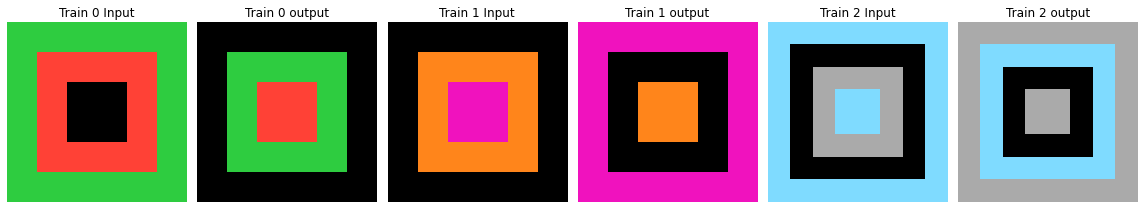

obj_staus:  irr
running_objective:  [[[('nonbg-1pr', 'nonbg0', 'direct')], [('nonbg0', 'nonbg1', 'direct')], [('nonbg1', 'nonbg-1pr', 'direct')]], [[('nonbg-1pr', 'nonbg0', 'direct')], [('nonbg0', 'nonbg1', 'direct')], [('nonbg1', 'nonbg-1pr', 'direct')]], [[('nonbg-1pr', 'nonbg1', 'direct')], [('nonbg0', 'nonbg-1pr', 'direct')], [('nonbg1', 'nonbg0', 'direct')]]]
test_objective:  [[[('nonbg-1pr', 'nonbg0', 'direct')]], [[('nonbg-1pr', 'nonbg0', 'direct')]]]
test_running_objective:  [[('nonbg-1pr', 'nonbg0', 'direct')], [('nonbg0', 'nonbg1', 'direct')], [('nonbg1', 'nonbg-1pr', 'direct')]]
299


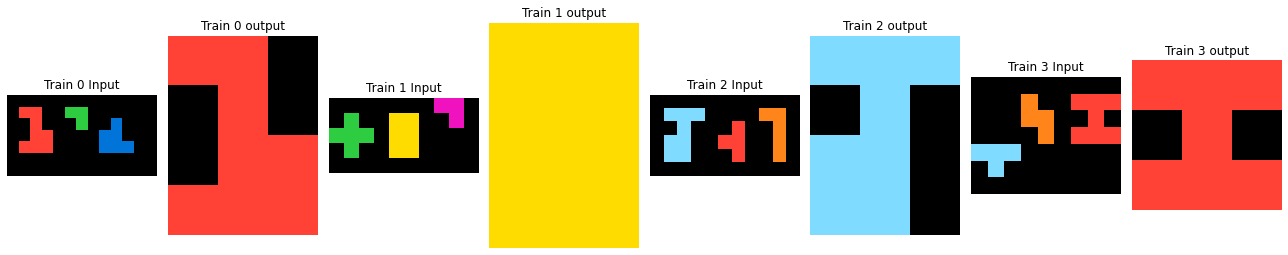

obj_staus:  irr
running_objective:  [[[('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]]
test_objective:  [[[('bg', 'bg', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]]
test_running_objective:  [[('nonbg0', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('bg', 'bg', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]
316


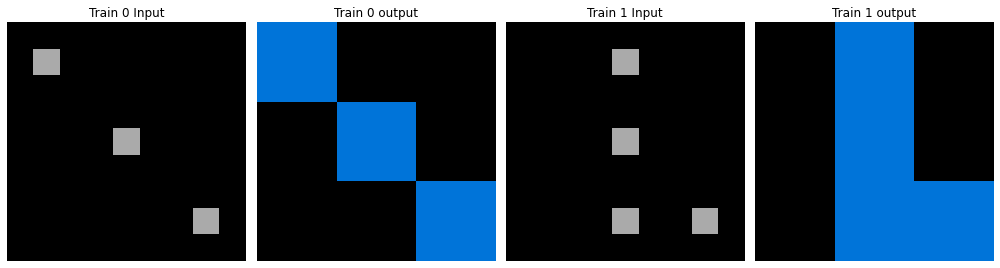

obj_staus:  obd
running_objective:  [[[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]]]
test_objective:  [[[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr')]]]
test_running_objective:  [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg'), ('bg', 'nonbg0pr'), [7], (7, {1}, {2})]]
328


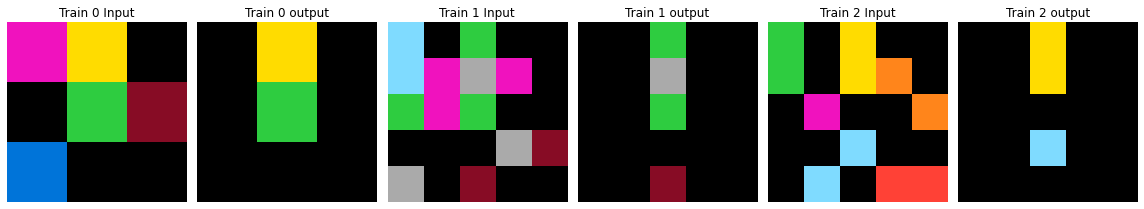

obj_staus:  irr
running_objective:  [[[('nonbg0pr', 'bg', 'direct')], [('nonbg1', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')]], [[('nonbg1pr', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'bg'), [3, 6], (3, {2}, {0}), (6, {7, 15}, {8})], [('nonbg3', 'nonbg3'), ('nonbg3', 'bg'), [2, 3, 6], (2, {4}, {3}), (3, {2}, {4}), (6, {13}, {14})], [('nonbg4', 'nonbg4'), ('nonbg4', 'bg'), [3, 6], (3, {2}, {0, 1, 3}), (6, {0, 13}, {8, 15})]], [[('nonbg0pr', 'bg', 'direct')], [('nonbg1pr', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')], [('nonbg3', 'bg', 'direct')], [('nonbg4', 'nonbg4'), ('nonbg4', 'bg'), [2, 3, 6, 7], (2, {3}, {4}), (3, {2}, {1}), (6, {13}, {8}), (7, {4}, {2})]]]
test_objective:  [[[('nonbg1pr', 'bg', 'direct')], [('nonbg2', 'bg', 'direct')], [('nonbg0pr', 'nonbg0pr'), ('nonbg0pr', 'bg')], [('nonbg3', 'nonbg3'), ('nonbg3', 'bg')], [('nonbg4', 'nonbg4'), ('nonbg4', 'bg')]]]
test_running_objective:  [[('nonbg1pr', 'bg', 'direct')], [('non

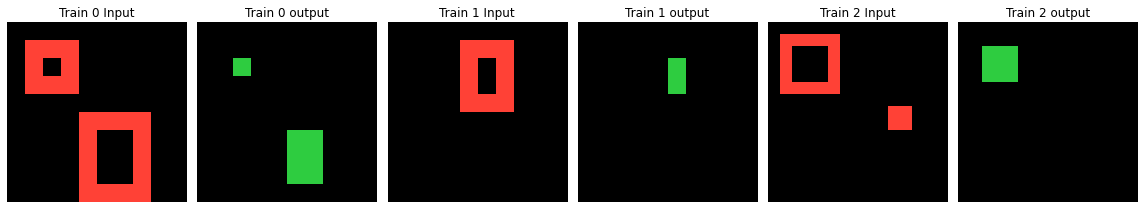

obj_staus:  obd
running_objective:  [[[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]], [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]], [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]]]
test_objective:  [[[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr')]], [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr')]]]
test_running_objective:  [[('nonbg0pr', 'bg', 'direct')], [('bg', 'bg'), ('bg', 'nonbg1pr'), [6], (6, {15}, {0})]]
345


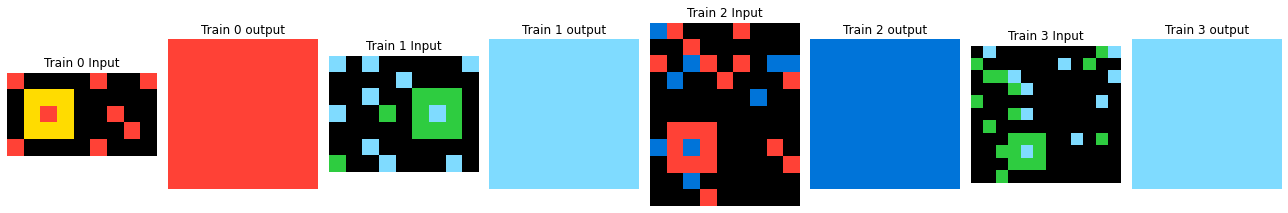

obj_staus:  irr
running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct')]], [[('bg', 'nil', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct'), [1, 6], (1, {8}), (6, {0})]], [[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 6], (1, {1}), (4, {9}), (5, {0}), (6, {5})]], [[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {8}), (4, {10}), (5, {0})]]]
test_objective:  [[[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct')]]]
test_running_objective:  [[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct')]]
365


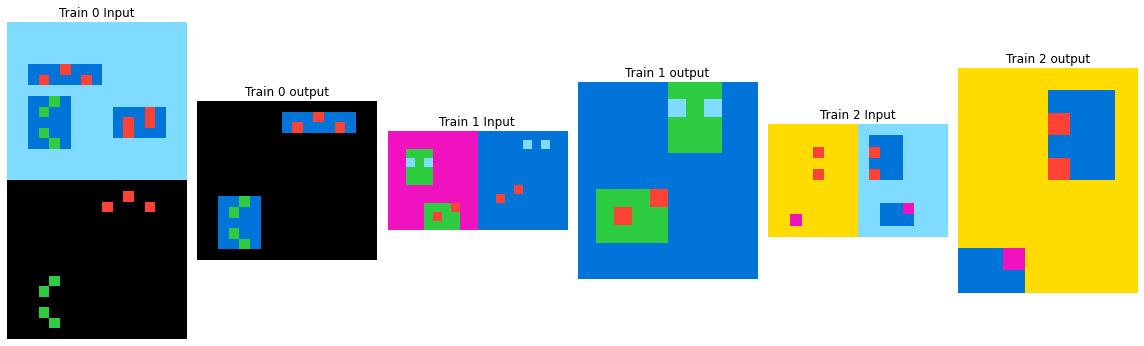

obj_staus:  irr
running_objective:  [[[('nonbg1pr', 'nil', 'direct')], [('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]], [[('nonbg3', 'nil', 'direct')], [('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nonbg1pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')]], [[('nonbg1pr', 'nil', 'direct')], [('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]]
test_objective:  [[[('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg1pr', 'nil', 'direct')], [('nonbg2', 'nonbg2', 'direct')]]]
test_running_objective:  [[('nonbg1pr', 'nil', 'direct')], [('nonbg-1pr', 'nonbg-1pr', 'direct')], [('nonbg0pr', 'nonbg0pr', 'direct')], [('nonbg2', 'nonbg2', 'direct')], [('nonbg3', 'nonbg3', 'direct')]]
372


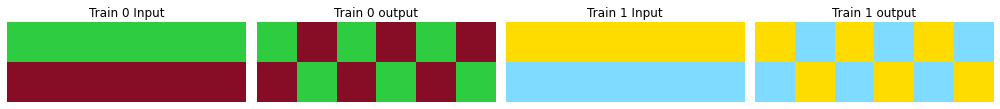

obj_staus:  obd
running_objective:  [[[('nonbg-1', 'nonbg-1'), ('nonbg-1', 'nonbg0'), [3], (3, {0, 2, 4}, {1, 3, 5})], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1'), [3], (3, {0, 2, 4}, {1, 3, 5})]], [[('nonbg-1', 'nonbg-1'), ('nonbg-1', 'nonbg0'), [3], (3, {0, 2, 4}, {1, 3, 5})], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1'), [3], (3, {0, 2, 4}, {1, 3, 5})]]]
test_objective:  [[[('nonbg-1', 'nonbg-1'), ('nonbg-1', 'nonbg0')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1')]]]
test_running_objective:  [[('nonbg-1', 'nonbg-1'), ('nonbg-1', 'nonbg0'), [3], (3, {0, 2, 4}, {1, 3, 5})], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1'), [3], (3, {0, 2, 4}, {1, 3, 5})]]
398


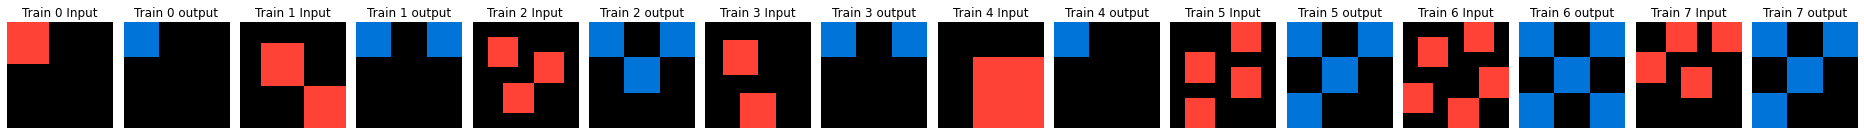

obj_staus:  irr
running_objective:  [[[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('bg', 'nonbg0pr', 'direct')], [('nonbg1pr', 'bg', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]]]
test_objective:  [[[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]], [[('nonbg1pr', 'nonbg0pr', 'direct')], [('bg', 'bg', 'direct')]]]
test_running_objective:  [[('bg', 'nonbg0pr', 'direct')], [('nonbg1pr', 'bg', 'direct')], [('bg', 'bg', 'direct')]]


In [14]:
current_attention = []
for n in range(400):
    this_task = previous_analysis[n]
    if this_task.is_complete_objective and this_task.test_running_objective != this_task.test_objective[0] and this_task.solved != 'solved':
        current_attention.append(n)
        print(n)
        plot_task(tt[n])
        print('obj_staus: ', this_task.objective_status)
        print('running_objective: ', this_task.running_objective)
        print('test_objective: ', this_task.test_objective)
        print('test_running_objective: ', this_task.test_running_objective)
        print('=========')
    

In [15]:
len(current_attention)

41

In [15]:
# tokenized_graph, in_, x_situation, y_situation, frequency_graph, sorted_frequency_graph, edge_situation, neighbor_situation
#         0         1       2            3              4                  5                    6                7

In [8]:
solved = 0
for n in knowns:
    print(n)
    this_task = Inductive(tt[n])
    if this_task.solved == 'solved':
        solved += 1
        print(this_task.solved)
        print(this_task.mechanisms)
        print('running_objective: ', this_task.running_objective)
        print('test_running_objective: ', this_task.test_running_objective)
    else:
        print('running_objective: ', this_task.running_objective)
        print('test_running_objective: ', this_task.test_running_objective)
    print('======')

1
running_objective:  [[[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {9, 5, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {5, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {9, 15}, {0})]], [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {15}, {0})]]]
test_running_objective:  [[('bg', 'bg'), ('bg', 'nonbg0pr'), [6], (6, {9, 5, 15}, {0})]]
86
solved
[<function screen_flips_rotation at 0x7f2cfef48820>]
running_objective:  [[[('nonbg-1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [3], (3, {1}, {2})], [('nonbg1', 'nonbg-1'), ('nonbg1', 'nonbg0'), [3], (3, {1, 2}, {0})], [('nonbg1', 'nonbg-1'), ('nonbg1', 'nonbg1'), [2, 3, 7], (2, {0}, {1}), (3, {1}, {0, 2}), (7, {2}, {3})], [('nonbg1', 'nonbg0'), ('nonbg1', 'nonbg1'), [2], (2, {0, 2}, {1})]], [[('nonbg-1', 'nonbg1', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [3, 6], (3, {1}, {2}), (6, {12}, {9, 7})], [('nonbg1', 'nonbg-1'), (

solved
[<function screen_flips_rotation at 0x7f2cfef48820>]
running_objective:  [[[('nonbg-1', 'nonbg-1'), ('nonbg-1', 'nonbg0'), [2, 3, 6], (2, {1}, {2}), (3, {1}, {0}), (6, {15}, {13})], [('nonbg0', 'nonbg-1'), ('nonbg0', 'nonbg1'), [2, 6], (2, {0}, {1}), (6, {11}, {9, 5})], [('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0'), [3], (3, {0, 2}, {1})]], [[('nonbg-1', 'nonbg0', 'direct')], [('nonbg0', 'nonbg-1'), ('nonbg0', 'nonbg0')], [('nonbg0', 'nonbg-1'), ('nonbg0', 'nonbg1'), [2], (2, {0, 2}, {0, 1})], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg1'), [3], (3, {0, 1}, {2})], [('nonbg1', 'nonbg1'), ('nonbg1', 'nonbg0'), [3], (3, {0, 2}, {1})]], [[('nonbg-1', 'nonbg-1'), ('nonbg-1', 'nonbg0'), [3, 6, 7], (3, {0, 2}, {1}), (6, {9, 12}, {15}), (7, {2}, {3})], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1')]], [[('nonbg-1', 'nonbg-1'), ('nonbg-1', 'nonbg0'), [3, 6], (3, {1}, {2}), (6, {12}, {9})], [('nonbg0', 'nonbg-1'), ('nonbg0', 'nonbg1'), [2, 6], (2, {2}, {0}), (6, {15}, {12, 7})], [('nonbg1', 'non

running_objective:  [[[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), []]], [[('bg', 'nil', 'direct')], [('nonbg0', 'nil', 'direct')], [('nonbg1', 'nonbg1', 'direct'), [1, 6], (1, {8}), (6, {0})]], [[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5, 6], (1, {1}), (4, {9}), (5, {0}), (6, {5})]], [[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), [1, 4, 5], (1, {8}), (4, {10}), (5, {0})]]]
test_running_objective:  [[('bg', 'nil', 'direct')], [('nonbg1', 'nil', 'direct')], [('nonbg0', 'nonbg0', 'direct'), []]]
379
solved
[<function screen_flips_rotation at 0x7f2cfef48820>]
running_objective:  [[[('nonbg-1pr', 'nonbg0', 'direct')], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1pr')]], [[('nonbg-1pr', 'nonbg-1pr'), ('nonbg-1pr', 'nonbg0'), [3], (3, {1}, {0, 2})], [('nonbg0', 'nonbg0'), ('nonbg0', 'nonbg-1pr'), [3], (3, {0}, {1, 2})]], [[('nonbg-1pr', 'nonbg-1pr')

In [9]:
coding_situation = {}
coding_situation[-1] = []
coding_situation[0] = []
coding_situation[1] = []


for n in range(len(previous_analysis)):
    this_task = previous_analysis[n]
    if this_task.objective_status == 'irr':
        coding_situation[-1].append(n)
    elif this_task.objective_status == 'obd':
        coding_situation[0].append(n)
    elif this_task.objective_status == 'red':
        coding_situation[1].append(n)

        
for k, v in coding_situation.items():
    print(k, ' : ', len(v))
# -1  :  64 # irr
# 0  :  245 # obd
# 1  :  91 # red 

# Evaluation (never inspected for now)
# -1  :  0
# 0  :  92
# 1  :  308

-1  :  64
0  :  245
1  :  91


In [10]:
def screen_all(previous_analysis):
    results = deepcopy(results_dict)
    
    for task in range(len(previous_analysis)):
        #print(task)
        this_task = deepcopy(previous_analysis[task])
        current_situation, train_situation, train_screen, test_situation, test_screen = this_task.current_situation, this_task.train_situation, this_task.train_screen, this_task.test_situation, this_task.test_screen
        
        if current_situation in results_dict.keys():
            results[current_situation].append(task)
        else:
            results['unknown'].append((task, current_situation))

    for k, v in results.items():
        print(k, ' : ', len(v))
    
    return results

screening_results = screen_all(previous_analysis)

serialize(screening_results, 'assets/screening_results')

ineligible  :  380
passed_all_traininputs  :  0
passed_some_traininputs  :  0
unpassed_all_traininputs  :  0
passed_all_testinputs  :  20
passed_some_testinputs  :  0
unpassed_all_testinputs  :  0
unknown  :  0


In [11]:
all_undeduced = 0
for n in previous_analysis:
    if n.dimension_status != 'deduced':
        all_undeduced += 1
all_undeduced

# training: 310 deduces: 0.775

95

In [13]:
knowns = load_serialized('assets/solved_indices_for_the_day.pkl')

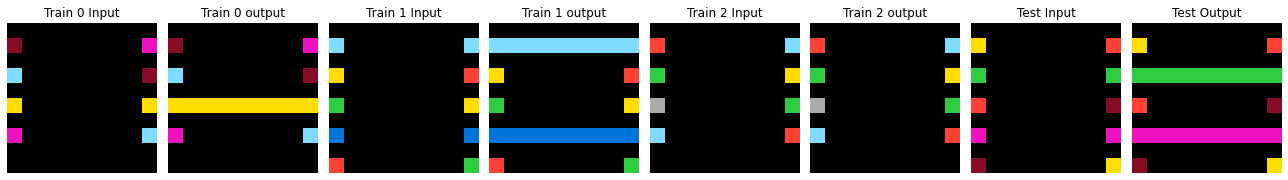

=====


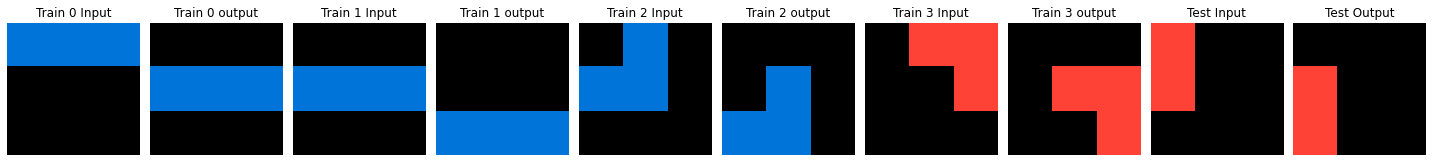

=====


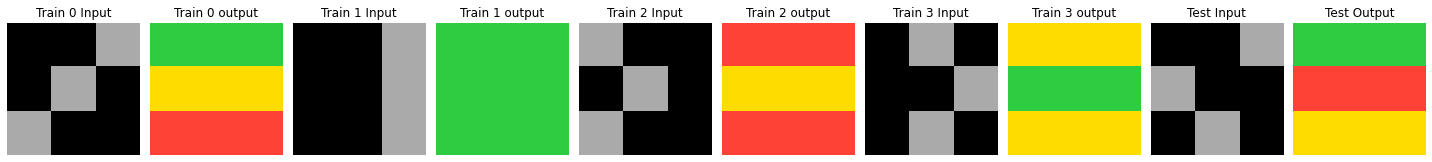

=====


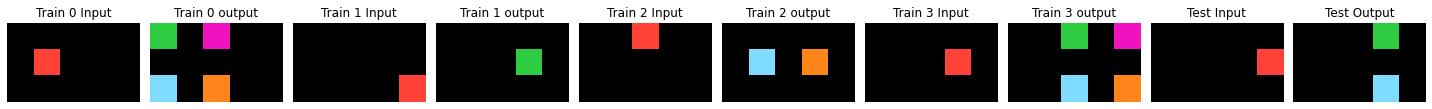

=====


In [14]:
# fix test_token_to_colors 44, 52, 261, 265! this is only unexplaied 1% of objectification failure.
for case in [44, 52, 261, 265]:
    plot_task(tt[case], True)
    print('=====')